# Fama-French Three Factor Model
## Evidence from Indian Equity Markets (Nifty 50 Universe)

---

### Model

The Fama-French Three Factor Model (Fama & French, 1993) extends the CAPM by adding two additional risk factors:

$$R_i - R_f = \alpha_i + \beta_i(R_m - R_f) + s_i \cdot SMB + h_i \cdot HML + \varepsilon_i$$

| Factor | Description | Theory |
|--------|-------------|--------|
| **MKT-RF** | Market excess return ($R_m - R_f$) | Compensation for systematic market risk |
| **SMB** | Small Minus Big | Small-cap premium — size effect |
| **HML** | High Minus Low (Book-to-Market) | Value premium — distress risk |
| **α** | Jensen's Alpha (intercept) | Abnormal return unexplained by the 3 factors |

### Factor Proxies (adapted for available data)
- **Size proxy**: Price × Rolling 21-day average volume (dollar turnover ≈ market cap proxy)
- **Value proxy**: $(P_{52wk\_high} - P) / P_{52wk\_high}$ — how far below the 52-week high (beaten-down = value)
- **Risk-free rate**: India 91-day T-Bill proxy = **6% p.a.** (≈ 0.487% per month)

### Data
- **Universe**: Nifty 50 constituent stocks
- **Indices**: NIFTY 50, BANK NIFTY, SENSEX
- **Period**: 2005–2025 (monthly frequency)
- **Rebalancing**: Monthly


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import os
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme config ─────────────────────────────────────────────────────────
BG     = '#0D1117'
PANEL  = '#161B22'
BORDER = '#30363D'
GRID   = '#21262D'
TEXT   = '#E6EDF3'
MUTED  = '#8B949E'

plt.rcParams.update({
    'figure.facecolor'  : BG,
    'axes.facecolor'    : PANEL,
    'axes.edgecolor'    : BORDER,
    'axes.labelcolor'   : TEXT,
    'xtick.color'       : MUTED,
    'ytick.color'       : MUTED,
    'text.color'        : TEXT,
    'grid.color'        : GRID,
    'grid.alpha'        : 1.0,
    'grid.linewidth'    : 0.6,
    'legend.facecolor'  : PANEL,
    'legend.edgecolor'  : BORDER,
    'figure.titlesize'  : 15,
    'axes.titlesize'    : 12,
    'axes.labelsize'    : 10,
    'font.size'         : 10,
    'lines.linewidth'   : 1.8,
})

# ── Color palette ─────────────────────────────────────────────────────────────
C = {
    'mkt'       : '#00D4FF',   # Cyan
    'smb'       : '#FF6B6B',   # Coral red
    'hml'       : '#FFD700',   # Gold
    'nifty'     : '#00FF7F',   # Spring green
    'banknifty' : '#FF69B4',   # Hot pink
    'sensex'    : '#FF8C00',   # Dark orange
    'alpha'     : '#B19CD9',   # Lavender
    'pos'       : '#2EA043',   # Green
    'neg'       : '#F85149',   # Red
    'neutral'   : '#8B949E',   # Gray
}

print('✓ Imports loaded | Dark theme configured')

✓ Imports loaded | Dark theme configured


In [2]:
# ── Constants ─────────────────────────────────────────────────────────────────
DATA_DIR    = '../dataset'
RF_ANNUAL   = 0.06                              # India risk-free rate proxy (6% p.a.)
RF_MONTHLY  = (1 + RF_ANNUAL) ** (1/12) - 1    # ≈ 0.487%
START       = '2005-01-01'
END         = '2025-12-31'

# ── Loader ────────────────────────────────────────────────────────────────────
def load_csv(ticker):
    df = pd.read_csv(os.path.join(DATA_DIR, f'{ticker}.csv'))
    df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_localize(None)
    df.set_index('date', inplace=True)
    df.sort_index(inplace=True)
    return df

# ── Load indices ──────────────────────────────────────────────────────────────
nifty     = load_csv('NIFTY')
banknifty = load_csv('BANKNIFTY')
sensex    = load_csv('SENSEX')

# ── Load all Nifty50 stocks ───────────────────────────────────────────────────
SKIP = {'NIFTY', 'BANKNIFTY', 'SENSEX'}
tickers = [f.replace('.csv','') for f in os.listdir(DATA_DIR)
           if f.endswith('.csv') and f.replace('.csv','') not in SKIP]

stocks = {}
for t in tickers:
    try:
        stocks[t] = load_csv(t)
    except Exception:
        pass

print(f'✓ Loaded {len(stocks)} stocks  |  Indices: NIFTY, BANKNIFTY, SENSEX')
print(f'  Data range: {nifty.index[0].date()} → {nifty.index[-1].date()}')

✓ Loaded 49 stocks  |  Indices: NIFTY, BANKNIFTY, SENSEX
  Data range: 2000-01-02 → 2026-04-29


In [3]:
# ── Monthly close prices → monthly returns ────────────────────────────────────
def monthly_returns(df, col='close'):
    return df[col].resample('ME').last().pct_change().dropna()

nifty_m     = monthly_returns(nifty).loc[START:END]
banknifty_m = monthly_returns(banknifty).loc[START:END]
sensex_m    = monthly_returns(sensex).loc[START:END]

# Stock returns matrix
stock_ret = {}
for t, df in stocks.items():
    r = monthly_returns(df).loc[START:END]
    if len(r) > 60:   # at least 5 years of data
        stock_ret[t] = r

returns_df = pd.DataFrame(stock_ret)

# ── Market factor: NIFTY excess return ───────────────────────────────────────
mkt_rf = (nifty_m - RF_MONTHLY)
mkt_rf.name = 'MKT-RF'

print(f'✓ Returns matrix: {returns_df.shape[0]} months × {returns_df.shape[1]} stocks')
print(f'  Analysis period: {returns_df.index[0].date()} → {returns_df.index[-1].date()}')
print(f'  Risk-free rate:  {RF_MONTHLY*100:.4f}% / month  ({RF_ANNUAL*100:.1f}% / year)')
print(f'\nMarket Factor (MKT-RF):')
print(f'  Annualized mean : {mkt_rf.mean()*12:+.2%}')
print(f'  Annualized vol  : {mkt_rf.std()*np.sqrt(12):.2%}')
print(f'  Sharpe ratio    : {mkt_rf.mean()/mkt_rf.std()*np.sqrt(12):.3f}')

✓ Returns matrix: 252 months × 49 stocks
  Analysis period: 2005-01-31 → 2025-12-31
  Risk-free rate:  0.4868% / month  (6.0% / year)

Market Factor (MKT-RF):
  Annualized mean : +8.63%
  Annualized vol  : 21.57%
  Sharpe ratio    : 0.400


## Factor Construction

### SMB — Size Factor
Each month, stocks are ranked by **size proxy** = `price × 21-day avg volume` (dollar turnover as market cap proxy).
- **Small portfolio**: Bottom 50% by size
- **Big portfolio**: Top 50% by size  
$$SMB_t = \bar{R}_{small,t} - \bar{R}_{big,t}$$

### HML — Value Factor
Each month, stocks are ranked by **value proxy** = $(P_{252d\_high} - P) / P_{252d\_high}$  
(higher score = more beaten down relative to 52-week high = more value-like).
- **Value portfolio**: Top 50% by value signal (High B/M)
- **Growth portfolio**: Bottom 50% by value signal (Low B/M)  
$$HML_t = \bar{R}_{value,t} - \bar{R}_{growth,t}$$

> Portfolio formation uses **lagged** signals (prior month-end) to avoid look-ahead bias.

In [4]:
print('Computing daily signals (size + value)...')

size_signals  = {}
value_signals = {}

for ticker, df in stocks.items():
    # Size proxy: price × 21-day rolling avg volume (dollar turnover)
    df_w = df.copy()
    df_w['size_proxy']  = df_w['close'] * df_w['volume'].rolling(21, min_periods=10).mean()
    size_signals[ticker] = df_w['size_proxy'].resample('ME').last()

    # Value proxy: (52wk high − current price) / 52wk high
    roll_high = df_w['close'].rolling(252, min_periods=60).max()
    df_w['value_proxy'] = (roll_high - df_w['close']) / roll_high
    value_signals[ticker] = df_w['value_proxy'].resample('ME').last()

size_df  = pd.DataFrame(size_signals).loc[START:END]
value_df = pd.DataFrame(value_signals).loc[START:END]

print(f'✓ Signal matrices: size {size_df.shape}, value {value_df.shape}')

Computing daily signals (size + value)...
✓ Signal matrices: size (252, 49), value (252, 49)


In [5]:
print('Constructing SMB and HML factor portfolios (monthly rebalancing)...')

dates   = returns_df.index
smb_vals, hml_vals, out_dates = [], [], []

for i in range(1, len(dates)):
    curr_date = dates[i]
    prev_date = dates[i - 1]

    # ── Current month returns ─────────────────────────────────────────────────
    r_curr = returns_df.loc[curr_date].dropna()
    if len(r_curr) < 8:
        continue

    # ── Lagged signals ────────────────────────────────────────────────────────
    if prev_date not in size_df.index or prev_date not in value_df.index:
        continue

    sz = size_df.loc[prev_date,  r_curr.index].dropna()
    vl = value_df.loc[prev_date, r_curr.index].dropna()

    common = r_curr.index.intersection(sz.index).intersection(vl.index)
    if len(common) < 6:
        continue

    r, sz, vl = r_curr[common], sz[common], vl[common]

    # SMB
    m_sz  = sz.median()
    smb_v = r[sz <= m_sz].mean() - r[sz > m_sz].mean()

    # HML
    m_vl  = vl.median()
    hml_v = r[vl >= m_vl].mean() - r[vl < m_vl].mean()

    smb_vals.append(smb_v)
    hml_vals.append(hml_v)
    out_dates.append(curr_date)

smb = pd.Series(smb_vals, index=out_dates, name='SMB')
hml = pd.Series(hml_vals, index=out_dates, name='HML')

# ── Align all three factors ───────────────────────────────────────────────────
common_idx = mkt_rf.index.intersection(smb.index).intersection(hml.index)
factors = pd.DataFrame({
    'MKT-RF': mkt_rf[common_idx],
    'SMB'   : smb[common_idx],
    'HML'   : hml[common_idx],
}).dropna()

print(f'✓ Factor series constructed: {len(factors)} monthly observations')
print(f'  Period: {factors.index[0].date()} → {factors.index[-1].date()}')

Constructing SMB and HML factor portfolios (monthly rebalancing)...
✓ Factor series constructed: 251 monthly observations
  Period: 2005-02-28 → 2025-12-31


In [6]:
# ── Factor Summary Statistics ─────────────────────────────────────────────────
def factor_stats(series):
    s = series.dropna()
    t_stat, p_val = stats.ttest_1samp(s, 0)
    return {
        'Mean (Monthly)':   f"{s.mean()*100:+.3f}%",
        'Mean (Ann.)':      f"{s.mean()*12*100:+.2f}%",
        'Vol (Ann.)':       f"{s.std()*np.sqrt(12)*100:.2f}%",
        'Sharpe (Ann.)':    f"{s.mean()/s.std()*np.sqrt(12):.3f}",
        'Skewness':         f"{s.skew():.3f}",
        'Excess Kurtosis':  f"{s.kurtosis():.3f}",
        'Min':              f"{s.min()*100:.2f}%",
        'Max':              f"{s.max()*100:.2f}%",
        't-stat (H₀=0)':    f"{t_stat:.3f}",
        'p-value':          f"{p_val:.4f}",
        'Sig. (5%)':        '✓ Yes' if p_val < 0.05 else '✗ No',
    }

summary = pd.DataFrame({col: factor_stats(factors[col]) for col in factors.columns})
print('═' * 62)
print('         FAMA-FRENCH FACTOR STATISTICS (2005–2025)')
print('═' * 62)
print(summary.to_string())
print('═' * 62)

══════════════════════════════════════════════════════════════
         FAMA-FRENCH FACTOR STATISTICS (2005–2025)
══════════════════════════════════════════════════════════════
                  MKT-RF      SMB      HML
Mean (Monthly)   +0.728%  +0.854%  +0.233%
Mean (Ann.)       +8.73%  +10.25%   +2.80%
Vol (Ann.)        21.60%    9.96%   16.12%
Sharpe (Ann.)      0.404    1.030    0.174
Skewness          -0.354    0.552    1.507
Excess Kurtosis    4.672    1.325    8.278
Min              -27.45%   -8.35%  -15.62%
Max               29.91%   13.68%   29.94%
t-stat (H₀=0)      1.849    4.709    0.795
p-value           0.0657   0.0000   0.4275
Sig. (5%)           ✗ No    ✓ Yes     ✗ No
══════════════════════════════════════════════════════════════


---
## Visualizations

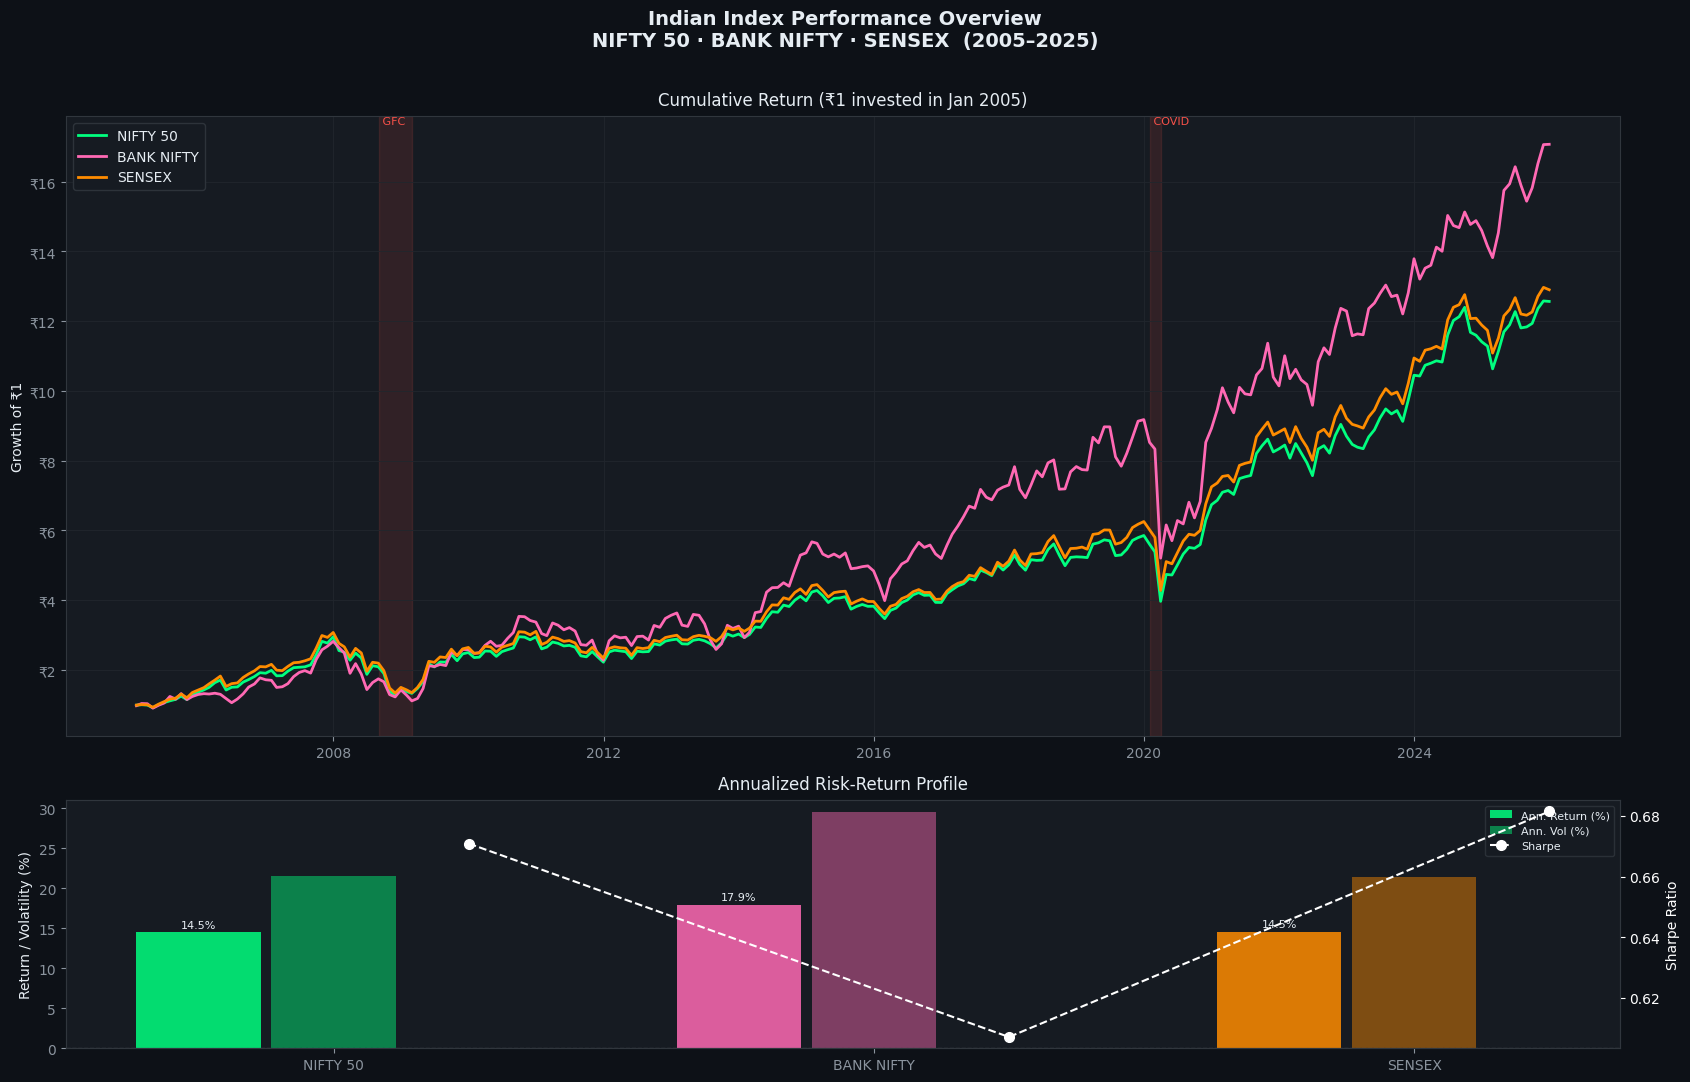

In [7]:
# ── Figure 1: Index Performance Overview ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(17, 11),
                         gridspec_kw={'height_ratios': [3, 1.2]})
fig.suptitle('Indian Index Performance Overview\nNIFTY 50 · BANK NIFTY · SENSEX  (2005–2025)',
             fontsize=14, fontweight='bold', y=0.98)

ax = axes[0]
for name, series, color in [
        ('NIFTY 50',   nifty_m,     C['nifty']),
        ('BANK NIFTY', banknifty_m, C['banknifty']),
        ('SENSEX',     sensex_m,    C['sensex'])]:
    s = series.loc[START:END]
    cum = (1 + s).cumprod()
    ax.plot(cum.index, cum.values, color=color, linewidth=2, label=name)

# Shade major drawdown events
events = [
    ('2008-09', '2009-03', 'GFC'),
    ('2020-02', '2020-04', 'COVID'),
]
for s, e, lbl in events:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.12, color=C['neg'], zorder=0)
    ax.text(pd.Timestamp(s), ax.get_ylim()[1] if ax.get_ylim()[1] > 1 else 2,
            f' {lbl}', color=C['neg'], fontsize=8, va='top')

ax.set_title('Cumulative Return (₹1 invested in Jan 2005)', pad=8)
ax.set_ylabel('Growth of ₹1')
ax.legend(loc='upper left', framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}'))
ax.grid(True)

ax2 = axes[1]
bar_data  = {'NIFTY 50': nifty_m, 'BANK NIFTY': banknifty_m, 'SENSEX': sensex_m}
bar_cols  = [C['nifty'], C['banknifty'], C['sensex']]
bar_names = list(bar_data.keys())
bar_means = [v.loc[START:END].mean() * 12 * 100 for v in bar_data.values()]
bar_vols  = [v.loc[START:END].std() * np.sqrt(12) * 100 for v in bar_data.values()]
bar_sharpe = [m/v for m, v in zip(bar_means, bar_vols)]

x = np.arange(3)
bars = ax2.bar(x - 0.25, bar_means,  0.23, color=bar_cols, alpha=0.85, label='Ann. Return (%)')
bars2 = ax2.bar(x,         bar_vols,  0.23, color=bar_cols, alpha=0.45, label='Ann. Vol (%)')
ax2b = ax2.twinx()
ax2b.plot(x + 0.25, bar_sharpe, 'o--', color='white', linewidth=1.5, markersize=7, label='Sharpe')
ax2b.set_ylabel('Sharpe Ratio', color='white')
ax2b.tick_params(colors='white')
ax2.set_xticks(x)
ax2.set_xticklabels(bar_names)
ax2.set_ylabel('Return / Volatility (%)')
ax2.set_title('Annualized Risk-Return Profile', pad=8)
ax2.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')

for bar, val in zip(bars, bar_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8, color=TEXT)

handles1, labels1 = ax2.get_legend_handles_labels()
handles2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper right', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('fig1_index_performance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

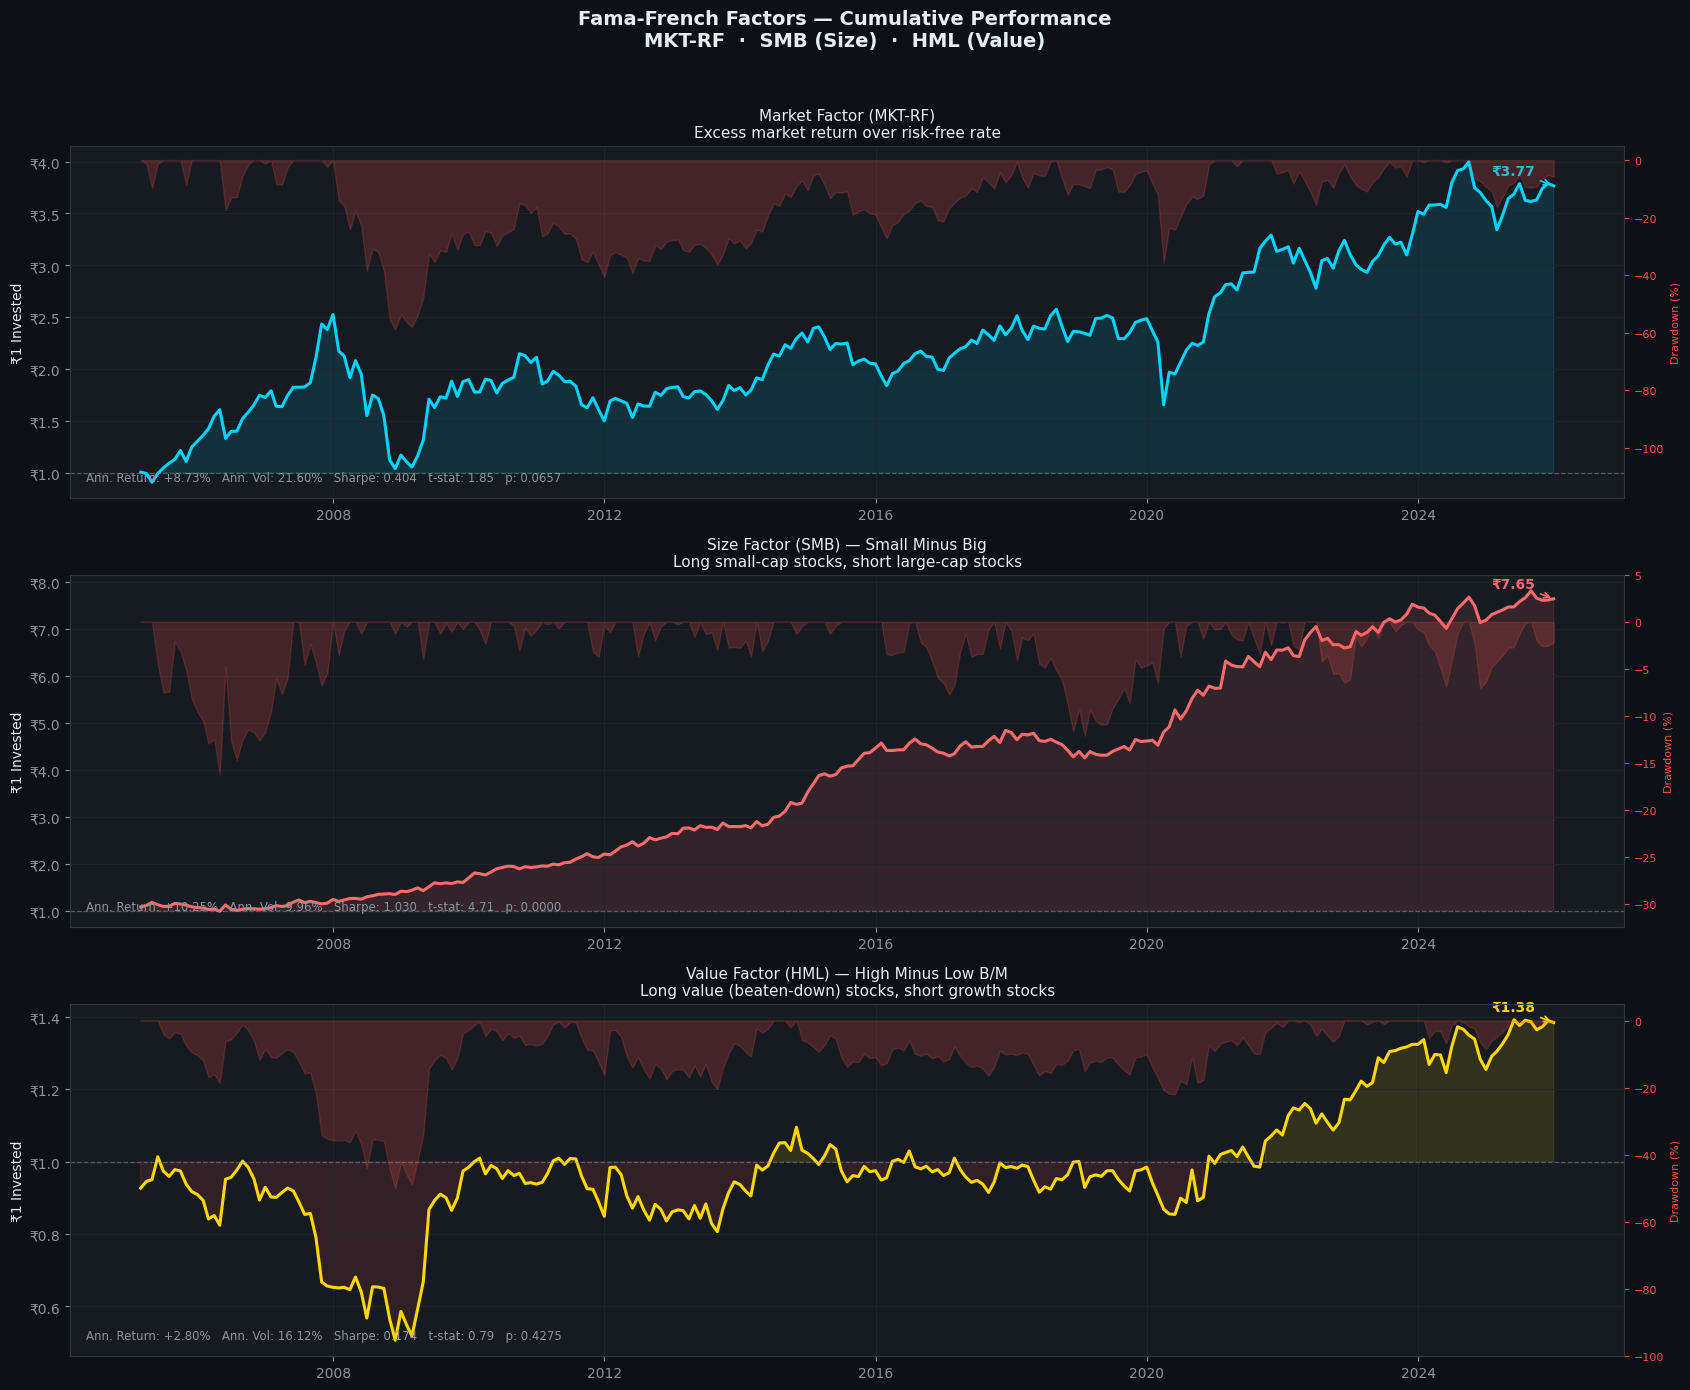

In [8]:
# ── Figure 2: Cumulative Factor Returns ──────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(17, 14))
fig.suptitle('Fama-French Factors — Cumulative Performance\n'
             'MKT-RF  ·  SMB (Size)  ·  HML (Value)',
             fontsize=14, fontweight='bold', y=0.99)

factor_meta = [
    ('MKT-RF', C['mkt'],
     'Market Factor (MKT-RF)',
     'Excess market return over risk-free rate'),
    ('SMB', C['smb'],
     'Size Factor (SMB) — Small Minus Big',
     'Long small-cap stocks, short large-cap stocks'),
    ('HML', C['hml'],
     'Value Factor (HML) — High Minus Low B/M',
     'Long value (beaten-down) stocks, short growth stocks'),
]

cum_factors = (1 + factors).cumprod()

for ax, (col, color, title, subtitle) in zip(axes, factor_meta):
    y = cum_factors[col]

    ax.plot(y.index, y.values, color=color, linewidth=2.2, label=col)
    ax.axhline(y=1, color=MUTED, linestyle='--', alpha=0.5, linewidth=0.9)

    ax.fill_between(y.index, 1, y.values,
                    where=(y.values >= 1), alpha=0.12, color=color)
    ax.fill_between(y.index, 1, y.values,
                    where=(y.values < 1),  alpha=0.12, color=C['neg'])

    # Annotate final value
    final_val = y.iloc[-1]
    ax.annotate(f'₹{final_val:.2f}',
                xy=(y.index[-1], final_val),
                xytext=(-45, 8), textcoords='offset points',
                color=color, fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

    # Drawdown shading
    running_max = y.cummax()
    drawdown    = y / running_max - 1
    ax2 = ax.twinx()
    ax2.fill_between(drawdown.index, 0, drawdown.values * 100,
                     alpha=0.2, color=C['neg'], label='Drawdown')
    ax2.set_ylabel('Drawdown (%)', color=C['neg'], fontsize=8)
    ax2.tick_params(colors=C['neg'], labelsize=8)
    ax2.set_ylim(drawdown.min() * 200, 5)

    # Factor stats box
    ann_ret = factors[col].mean() * 12 * 100
    ann_vol = factors[col].std() * np.sqrt(12) * 100
    sharpe  = factors[col].mean() / factors[col].std() * np.sqrt(12)
    t_s, p_v = stats.ttest_1samp(factors[col].dropna(), 0)
    stats_text = (f'Ann. Return: {ann_ret:+.2f}%   '
                  f'Ann. Vol: {ann_vol:.2f}%   '
                  f'Sharpe: {sharpe:.3f}   '
                  f't-stat: {t_s:.2f}   p: {p_v:.4f}')
    ax.set_title(f'{title}\n{subtitle}', pad=6, fontsize=11)
    ax.text(0.01, 0.04, stats_text, transform=ax.transAxes,
            fontsize=8.5, color=MUTED, va='bottom')
    ax.set_ylabel('₹1 Invested')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}'))
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('fig2_factor_cumulative.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

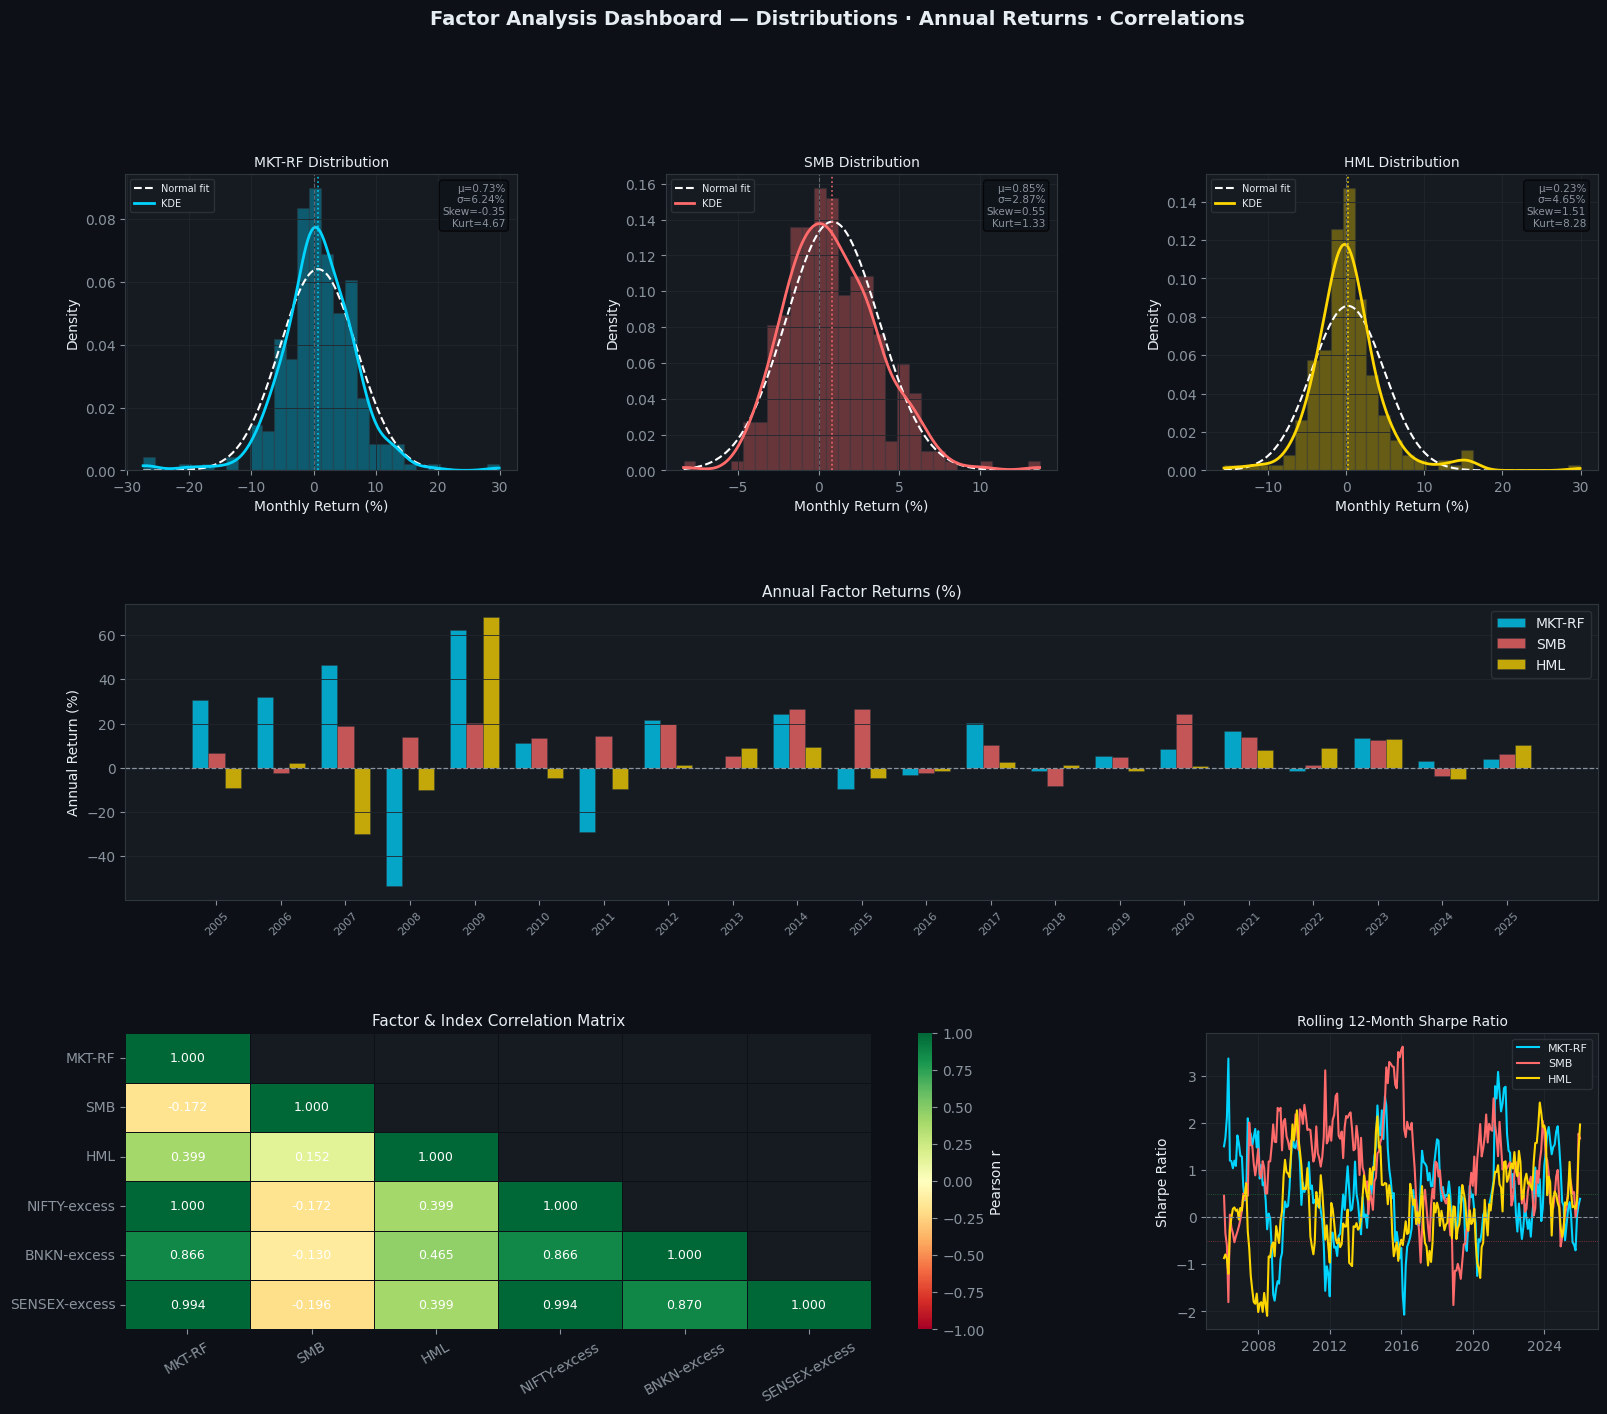

In [9]:
# ── Figure 3: Factor Analysis Dashboard ─────────────────────────────────────
fig = plt.figure(figsize=(19, 15))
fig.suptitle('Factor Analysis Dashboard — Distributions · Annual Returns · Correlations',
             fontsize=14, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

factor_colors = {'MKT-RF': C['mkt'], 'SMB': C['smb'], 'HML': C['hml']}

# Row 0: Return distributions
for j, (col, color) in enumerate(factor_colors.items()):
    ax = fig.add_subplot(gs[0, j])
    s  = factors[col] * 100

    ax.hist(s, bins=30, color=color, alpha=0.35, density=True, edgecolor=BORDER)
    xs = np.linspace(s.min(), s.max(), 200)
    mu, sigma = s.mean(), s.std()
    ax.plot(xs, stats.norm.pdf(xs, mu, sigma), color='white', linewidth=1.5,
            linestyle='--', label='Normal fit')
    kde = stats.gaussian_kde(s)
    ax.plot(xs, kde(xs), color=color, linewidth=2, label='KDE')
    ax.axvline(mu, color=color, linewidth=1.2, linestyle=':', alpha=0.9)
    ax.axvline(0,  color=MUTED, linewidth=0.8, linestyle='--', alpha=0.6)

    ax.set_title(f'{col} Distribution', fontsize=10)
    ax.set_xlabel('Monthly Return (%)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.text(0.97, 0.97, f'μ={mu:.2f}%\nσ={sigma:.2f}%\nSkew={s.skew():.2f}\nKurt={s.kurtosis():.2f}',
            transform=ax.transAxes, va='top', ha='right', fontsize=7.5,
            color=MUTED, bbox=dict(boxstyle='round,pad=0.3', facecolor=BG, alpha=0.7))
    ax.grid(True)

# Row 1: Annual factor returns (grouped bars)
ax_ann = fig.add_subplot(gs[1, :])
annual = factors.resample('YE').apply(lambda x: (1 + x).prod() - 1) * 100
years  = annual.index.year
x      = np.arange(len(years))
w      = 0.25

for i, (col, color) in enumerate(factor_colors.items()):
    offset = (i - 1) * w
    heights = annual[col].values
    bar_colors = [C['pos'] if v >= 0 else C['neg'] for v in heights]
    bars = ax_ann.bar(x + offset, heights, w, color=color, alpha=0.75,
                      edgecolor=BORDER, linewidth=0.4, label=col)

ax_ann.axhline(0, color=MUTED, linewidth=0.9, linestyle='--')
ax_ann.set_xticks(x)
ax_ann.set_xticklabels(years, rotation=45, fontsize=8)
ax_ann.set_title('Annual Factor Returns (%)', fontsize=11)
ax_ann.set_ylabel('Annual Return (%)')
ax_ann.legend(loc='upper right')
ax_ann.grid(True, axis='y')

# Row 2 left: Correlation heatmap
ax_corr = fig.add_subplot(gs[2, :2])
# Include index excess returns in correlation
corr_data = factors.copy()
corr_data['NIFTY-excess']     = nifty_m.loc[factors.index]     - RF_MONTHLY
corr_data['BNKN-excess']      = banknifty_m.loc[factors.index] - RF_MONTHLY
corr_data['SENSEX-excess']    = sensex_m.loc[factors.index]    - RF_MONTHLY
corr_mat = corr_data.corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat, annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    ax=ax_corr, mask=mask,
    linewidths=0.5, linecolor=BG,
    annot_kws={'size': 9, 'color': 'white'},
    cbar_kws={'label': 'Pearson r'}
)
ax_corr.set_title('Factor & Index Correlation Matrix', fontsize=11)
ax_corr.tick_params(axis='x', rotation=30)

# Row 2 right: Rolling 12-month Sharpe
ax_sharpe = fig.add_subplot(gs[2, 2])
for col, color in factor_colors.items():
    rolling_sharpe = (factors[col].rolling(12).mean() /
                      factors[col].rolling(12).std() * np.sqrt(12))
    ax_sharpe.plot(rolling_sharpe.index, rolling_sharpe.values,
                   color=color, linewidth=1.5, label=col)

ax_sharpe.axhline(0,    color=MUTED, linewidth=0.8, linestyle='--')
ax_sharpe.axhline(0.5,  color=C['pos'],  linewidth=0.6, linestyle=':', alpha=0.6)
ax_sharpe.axhline(-0.5, color=C['neg'],  linewidth=0.6, linestyle=':', alpha=0.6)
ax_sharpe.set_title('Rolling 12-Month Sharpe Ratio', fontsize=10)
ax_sharpe.set_ylabel('Sharpe Ratio')
ax_sharpe.legend(fontsize=8)
ax_sharpe.grid(True)

plt.savefig('fig3_factor_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

---
## Regression Analysis

We run two regression specifications for each index:

**CAPM** (1 factor):
$$R_i - R_f = \alpha + \beta_1 (R_m - R_f) + \varepsilon$$

**Fama-French 3F** (3 factors):
$$R_i - R_f = \alpha + \beta_1 (R_m - R_f) + \beta_2 SMB + \beta_3 HML + \varepsilon$$

Standard errors are **HC3 heteroskedasticity-robust** following MacKinlay (1995).

**Interpretation:**
- $\alpha > 0$: Index earns abnormal returns unexplained by the factors  
- $\beta_2 (SMB) > 0$: Index tilts toward small-cap (positive size loading)  
- $\beta_3 (HML) > 0$: Index tilts toward value (positive value loading)  
- $\Delta R^2$: Improvement in explanatory power from CAPM → FF3

In [10]:
def run_regression(returns, factors, model='FF3'):
    """
    OLS with HC3 robust SEs.
    model: 'FF3' or 'CAPM'
    """
    excess = (returns - RF_MONTHLY).dropna()
    common = excess.index.intersection(factors.index)
    y = excess[common]
    if model == 'CAPM':
        X = sm.add_constant(factors.loc[common, ['MKT-RF']])
    else:
        X = sm.add_constant(factors.loc[common])
    return sm.OLS(y, X).fit(cov_type='HC3')

# ── Run regressions ───────────────────────────────────────────────────────────
indices = {
    'NIFTY 50'  : nifty_m,
    'BANK NIFTY': banknifty_m,
    'SENSEX'    : sensex_m,
}

results = {}
for name, series in indices.items():
    results[name] = {
        'capm': run_regression(series, factors, 'CAPM'),
        'ff3' : run_regression(series, factors, 'FF3'),
    }

# ── Pretty print results ──────────────────────────────────────────────────────
print('═' * 78)
print('      REGRESSION RESULTS: CAPM vs FAMA-FRENCH 3 FACTOR MODEL')
print('═' * 78)
params_order = ['const', 'MKT-RF', 'SMB', 'HML']
param_labels = {'const': 'α (Alpha)', 'MKT-RF': 'β₁ (MKT-RF)', 'SMB': 'β₂ (SMB)', 'HML': 'β₃ (HML)'}

for idx_name, res in results.items():
    print(f'\n── {idx_name} ──')
    print(f"{'':25} {'CAPM':>20} {'FF3':>20}")
    print(f"{'':25} {'Coeff    t-stat':>20} {'Coeff    t-stat':>20}")
    print('  ' + '-' * 70)
    for p in params_order:
        lbl  = param_labels.get(p, p)
        capm = res['capm']
        ff3  = res['ff3']
        if p in capm.params:
            sig_c = '***' if capm.pvalues[p] < 0.01 else ('**' if capm.pvalues[p] < 0.05 else
                    ('*' if capm.pvalues[p] < 0.10 else ''))
            c_str = f"{capm.params[p]:+.4f}{sig_c} ({capm.tvalues[p]:+.2f})"
        else:
            c_str = '—'
        if p in ff3.params:
            sig_f = '***' if ff3.pvalues[p] < 0.01 else ('**' if ff3.pvalues[p] < 0.05 else
                    ('*' if ff3.pvalues[p] < 0.10 else ''))
            f_str = f"{ff3.params[p]:+.4f}{sig_f} ({ff3.tvalues[p]:+.2f})"
        else:
            f_str = '—'
        print(f"  {lbl:25} {c_str:>25} {f_str:>25}")

    print(f"  {'R² (adj)':25} {capm.rsquared_adj:>25.4f} {ff3.rsquared_adj:>25.4f}")
    print(f"  {'ΔR² (FF3 - CAPM)':25} {'':>25} {ff3.rsquared_adj - capm.rsquared_adj:>+25.4f}")
    print(f"  {'Obs':25} {int(capm.nobs):>25} {int(ff3.nobs):>25}")

print('\n  Significance: * p<0.10  ** p<0.05  *** p<0.01  (HC3 robust SEs)')
print('═' * 78)

══════════════════════════════════════════════════════════════════════════════
      REGRESSION RESULTS: CAPM vs FAMA-FRENCH 3 FACTOR MODEL
══════════════════════════════════════════════════════════════════════════════

── NIFTY 50 ──
                                          CAPM                  FF3
                               Coeff    t-stat      Coeff    t-stat
  ----------------------------------------------------------------------
  α (Alpha)                           -0.0000 (-0.98)           +0.0000 (+1.37)
  β₁ (MKT-RF)               +1.0000*** (+13243660846068782.00) +1.0000*** (+26334605337829392.00)
  β₂ (SMB)                                          —        -0.0000*** (-4.02)
  β₃ (HML)                                          —        +0.0000*** (+5.17)
  R² (adj)                                     1.0000                    1.0000
  ΔR² (FF3 - CAPM)                                                      +0.0000
  Obs                                             251     

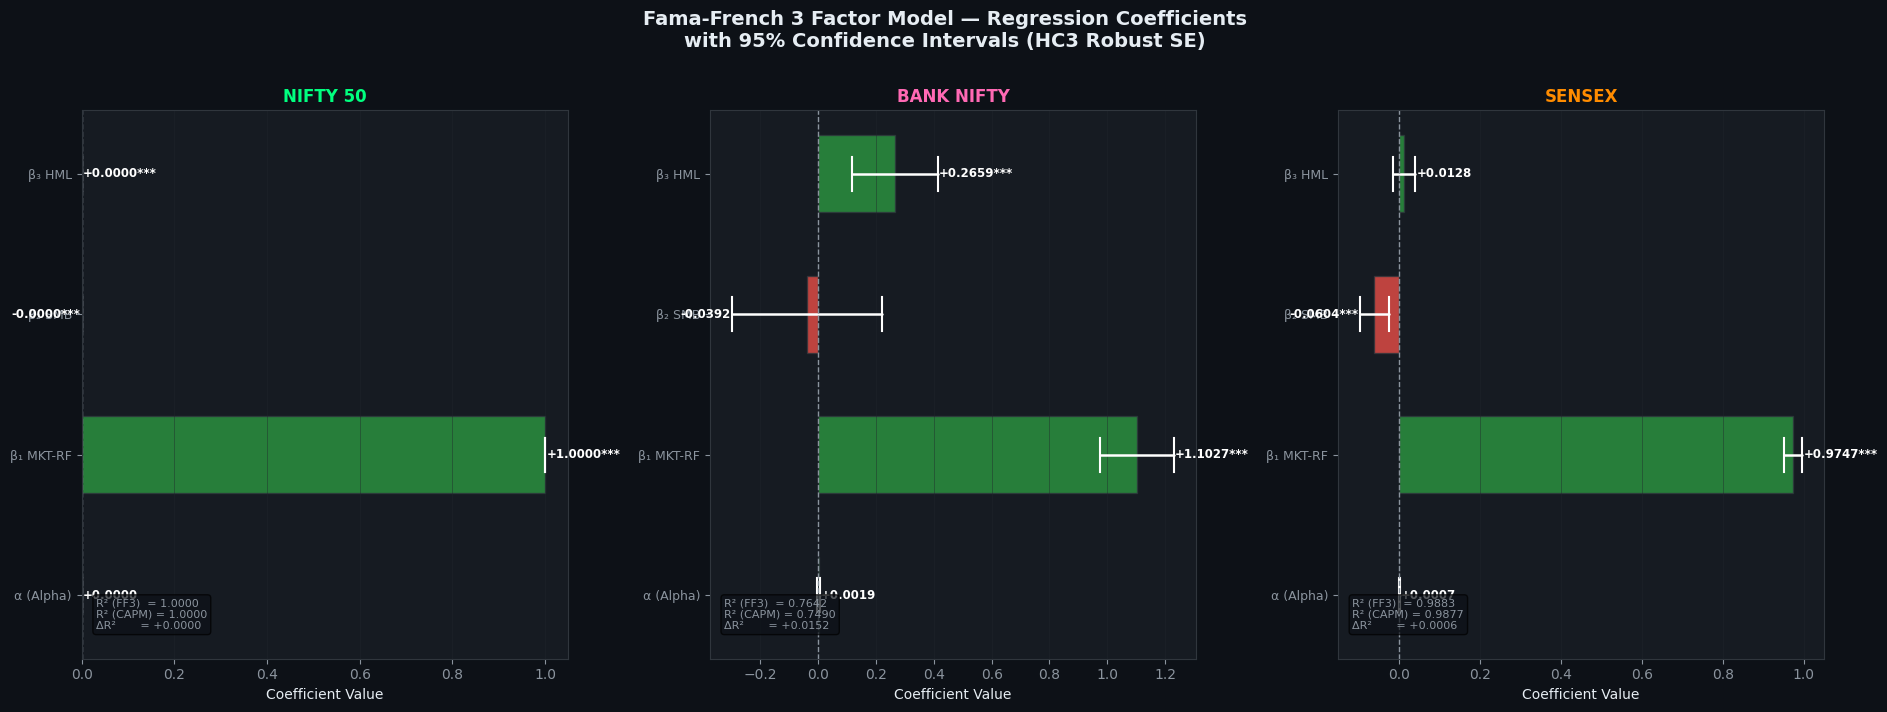

In [11]:
# ── Figure 4: Regression Coefficients Comparison ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 7), sharey=False)
fig.suptitle('Fama-French 3 Factor Model — Regression Coefficients\n'
             'with 95% Confidence Intervals (HC3 Robust SE)',
             fontsize=14, fontweight='bold', y=1.01)

idx_colors = {
    'NIFTY 50'  : C['nifty'],
    'BANK NIFTY': C['banknifty'],
    'SENSEX'    : C['sensex'],
}

for ax, (idx_name, res) in zip(axes, results.items()):
    model     = res['ff3']
    params    = ['const', 'MKT-RF', 'SMB', 'HML']
    labels    = ['α (Alpha)', 'β₁ MKT-RF', 'β₂ SMB', 'β₃ HML']
    coef_vals = [model.params.get(p, np.nan)   for p in params]
    ci_lo     = [model.conf_int().loc[p, 0] if p in model.conf_int().index else np.nan for p in params]
    ci_hi     = [model.conf_int().loc[p, 1] if p in model.conf_int().index else np.nan for p in params]
    pvals     = [model.pvalues.get(p, 1.0)     for p in params]

    y_pos  = np.arange(len(params))
    color  = idx_colors[idx_name]
    bar_cs = [C['pos'] if v >= 0 else C['neg'] for v in coef_vals]

    bars = ax.barh(y_pos, coef_vals, 0.55, color=bar_cs, alpha=0.75, edgecolor=BORDER)

    for y, lo, hi, v, p in zip(y_pos, ci_lo, ci_hi, coef_vals, pvals):
        ax.plot([lo, hi], [y, y], color='white', linewidth=1.8, solid_capstyle='round')
        ax.plot([lo, lo], [y - 0.12, y + 0.12], color='white', linewidth=1.5)
        ax.plot([hi, hi], [y - 0.12, y + 0.12], color='white', linewidth=1.5)
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
        offset = hi + 0.003 if v >= 0 else lo - 0.003
        ha_val = 'left' if v >= 0 else 'right'
        ax.text(offset, y, f'{v:+.4f}{sig}', va='center', ha=ha_val,
                fontsize=8.5, color='white', fontweight='bold')

    ax.axvline(0, color=MUTED, linewidth=1, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(idx_name, fontsize=12, color=color, fontweight='bold')
    ax.set_xlabel('Coefficient Value')
    ax.grid(True, axis='x', alpha=0.5)

    r2_ff3  = results[idx_name]['ff3'].rsquared_adj
    r2_capm = results[idx_name]['capm'].rsquared_adj
    ax.text(0.03, 0.05,
            f"R² (FF3)  = {r2_ff3:.4f}\n"
            f"R² (CAPM) = {r2_capm:.4f}\n"
            f"ΔR²       = {r2_ff3 - r2_capm:+.4f}",
            transform=ax.transAxes, fontsize=8, color=MUTED,
            va='bottom', bbox=dict(boxstyle='round', facecolor=BG, alpha=0.7))

plt.tight_layout()
plt.savefig('fig4_regression_coefficients.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

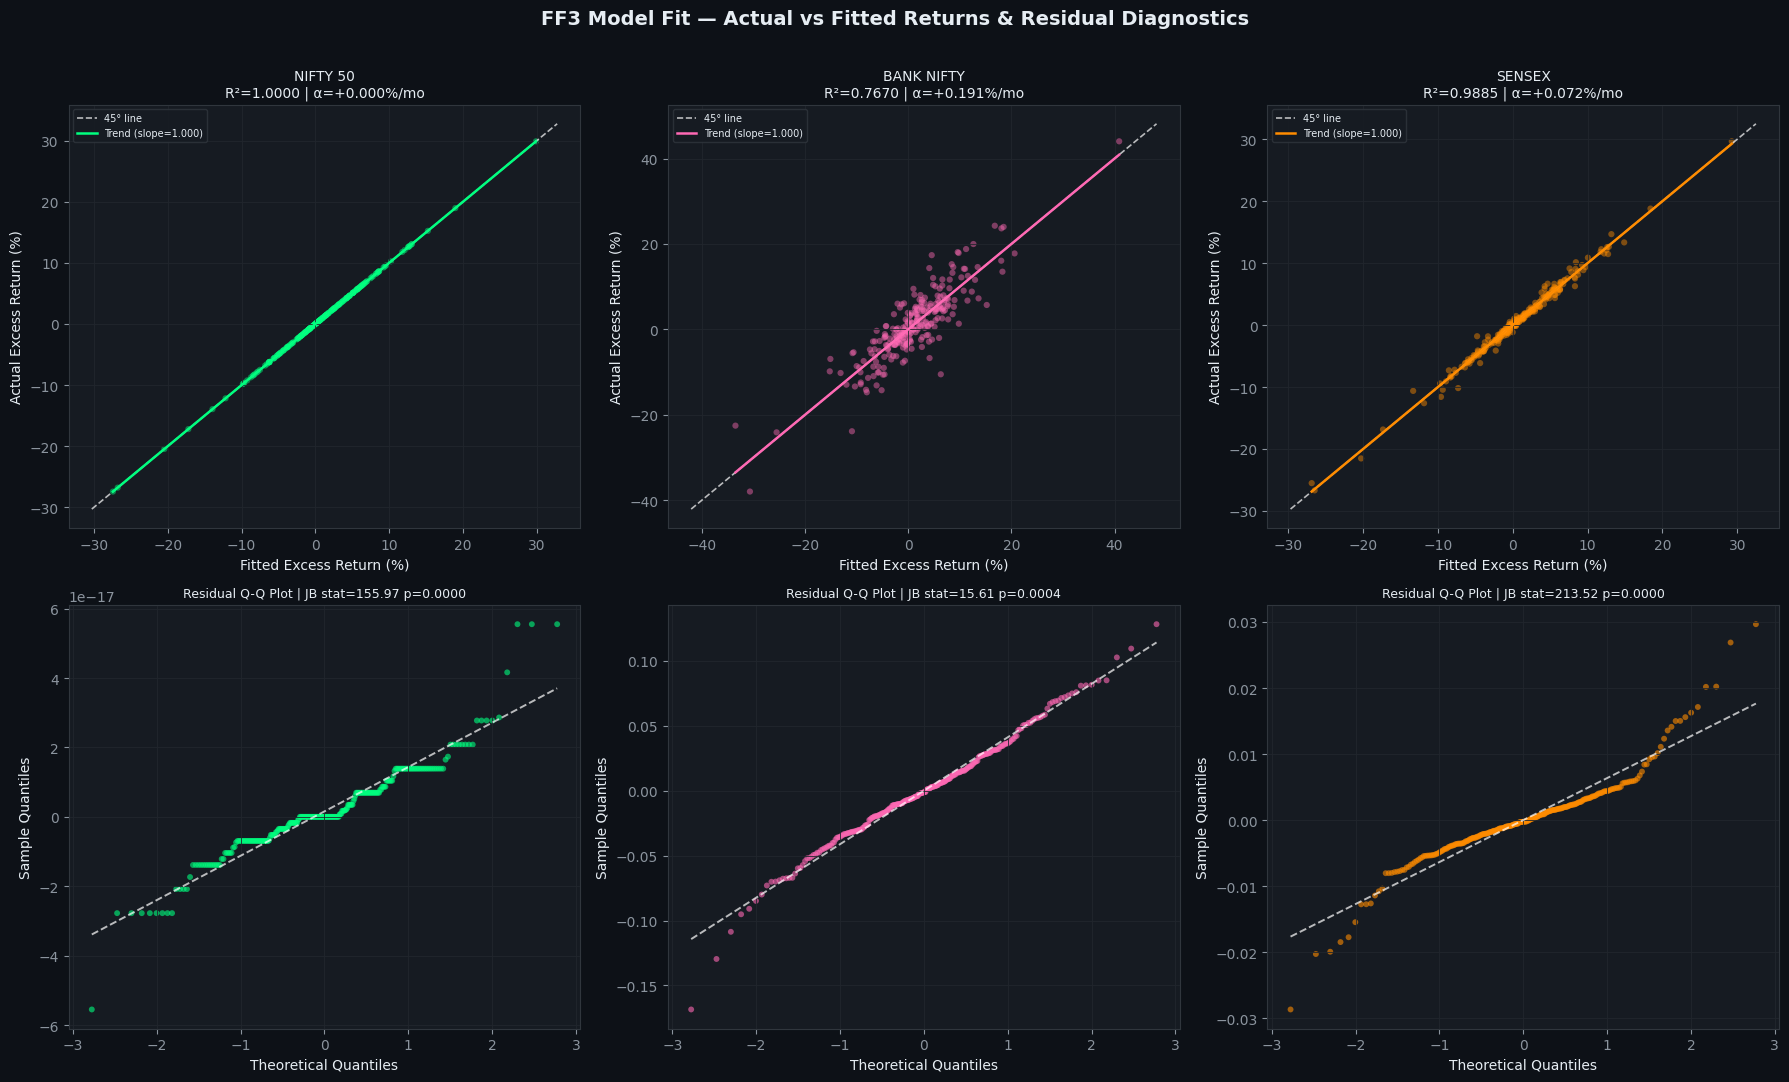

In [12]:
# ── Figure 5: Actual vs Fitted + Residuals ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('FF3 Model Fit — Actual vs Fitted Returns & Residual Diagnostics',
             fontsize=14, fontweight='bold')

idx_colors = ['nifty', 'banknifty', 'sensex']

for j, (idx_name, res) in enumerate(results.items()):
    model   = res['ff3']
    actual  = model.model.endog
    fitted  = model.fittedvalues.values
    resids  = model.resid.values
    color   = C[idx_colors[j]]

    # Top: Actual vs Fitted scatter
    ax_top = axes[0, j]
    ax_top.scatter(fitted * 100, actual * 100,
                   alpha=0.45, s=20, color=color, edgecolors='none')
    lims = np.array([min(fitted.min(), actual.min()),
                     max(fitted.max(), actual.max())]) * 100
    pad  = (lims[1] - lims[0]) * 0.05
    ax_top.plot([lims[0]-pad, lims[1]+pad], [lims[0]-pad, lims[1]+pad],
                color='white', linewidth=1.2, linestyle='--', alpha=0.7, label='45° line')
    m, b = np.polyfit(fitted, actual, 1)
    xs = np.linspace(fitted.min(), fitted.max(), 100)
    ax_top.plot(xs * 100, (m * xs + b) * 100, color=color,
                linewidth=1.8, label=f'Trend (slope={m:.3f})')

    ax_top.set_title(f'{idx_name}\nR²={model.rsquared:.4f} | α={model.params["const"]*100:+.3f}%/mo',
                     fontsize=10)
    ax_top.set_xlabel('Fitted Excess Return (%)')
    ax_top.set_ylabel('Actual Excess Return (%)')
    ax_top.legend(fontsize=7)
    ax_top.grid(True)

    # Bottom: Q-Q plot of residuals
    # stats.probplot returns ((theoretical_q, sample_q), (slope, intercept, r))
    ax_bot = axes[1, j]
    (osm, osr), (slope_qq, intercept_qq, _) = stats.probplot(resids, dist='norm')
    ax_bot.scatter(osm, osr, s=18, color=color, alpha=0.6, edgecolors='none')
    ax_bot.plot(osm, slope_qq * np.array(osm) + intercept_qq,
                color='white', linewidth=1.4, linestyle='--', alpha=0.7)
    jb_stat, jb_p = stats.jarque_bera(resids)
    ax_bot.set_title(f'Residual Q-Q Plot | JB stat={jb_stat:.2f} p={jb_p:.4f}',
                     fontsize=9)
    ax_bot.set_xlabel('Theoretical Quantiles')
    ax_bot.set_ylabel('Sample Quantiles')
    ax_bot.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('fig5_actual_vs_fitted.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

In [13]:
# ── Rolling 36-month regressions ─────────────────────────────────────────────
WINDOW = 36

def rolling_ff3(returns, factors, window=36):
    """Returns DataFrame of rolling OLS coefficients and R²."""
    excess = (returns - RF_MONTHLY).dropna()
    common = excess.index.intersection(factors.index)
    y      = excess[common]
    X      = sm.add_constant(factors.loc[common])

    records = []
    for i in range(window, len(y) + 1):
        yi, Xi = y.iloc[i - window:i], X.iloc[i - window:i]
        try:
            m = sm.OLS(yi, Xi).fit()
            records.append({
                'date'   : y.index[i - 1],
                'alpha'  : m.params.get('const', np.nan),
                'beta'   : m.params.get('MKT-RF', np.nan),
                'smb'    : m.params.get('SMB', np.nan),
                'hml'    : m.params.get('HML', np.nan),
                'r2'     : m.rsquared,
                'r2_adj' : m.rsquared_adj,
            })
        except Exception:
            pass

    return pd.DataFrame(records).set_index('date')

def rolling_capm(returns, factors, window=36):
    excess = (returns - RF_MONTHLY).dropna()
    common = excess.index.intersection(factors.index)
    y      = excess[common]
    X      = sm.add_constant(factors.loc[common, ['MKT-RF']])
    records = []
    for i in range(window, len(y) + 1):
        yi, Xi = y.iloc[i - window:i], X.iloc[i - window:i]
        try:
            m = sm.OLS(yi, Xi).fit()
            records.append({'date': y.index[i - 1], 'r2': m.rsquared})
        except Exception:
            pass
    return pd.DataFrame(records).set_index('date')

print(f'Computing rolling {WINDOW}-month regressions...')
rolling = {
    name: rolling_ff3(series, factors, WINDOW)
    for name, series in indices.items()
}
rolling_capm_r2 = {
    name: rolling_capm(series, factors, WINDOW)
    for name, series in indices.items()
}
print('✓ Rolling regressions complete')

Computing rolling 36-month regressions...
✓ Rolling regressions complete


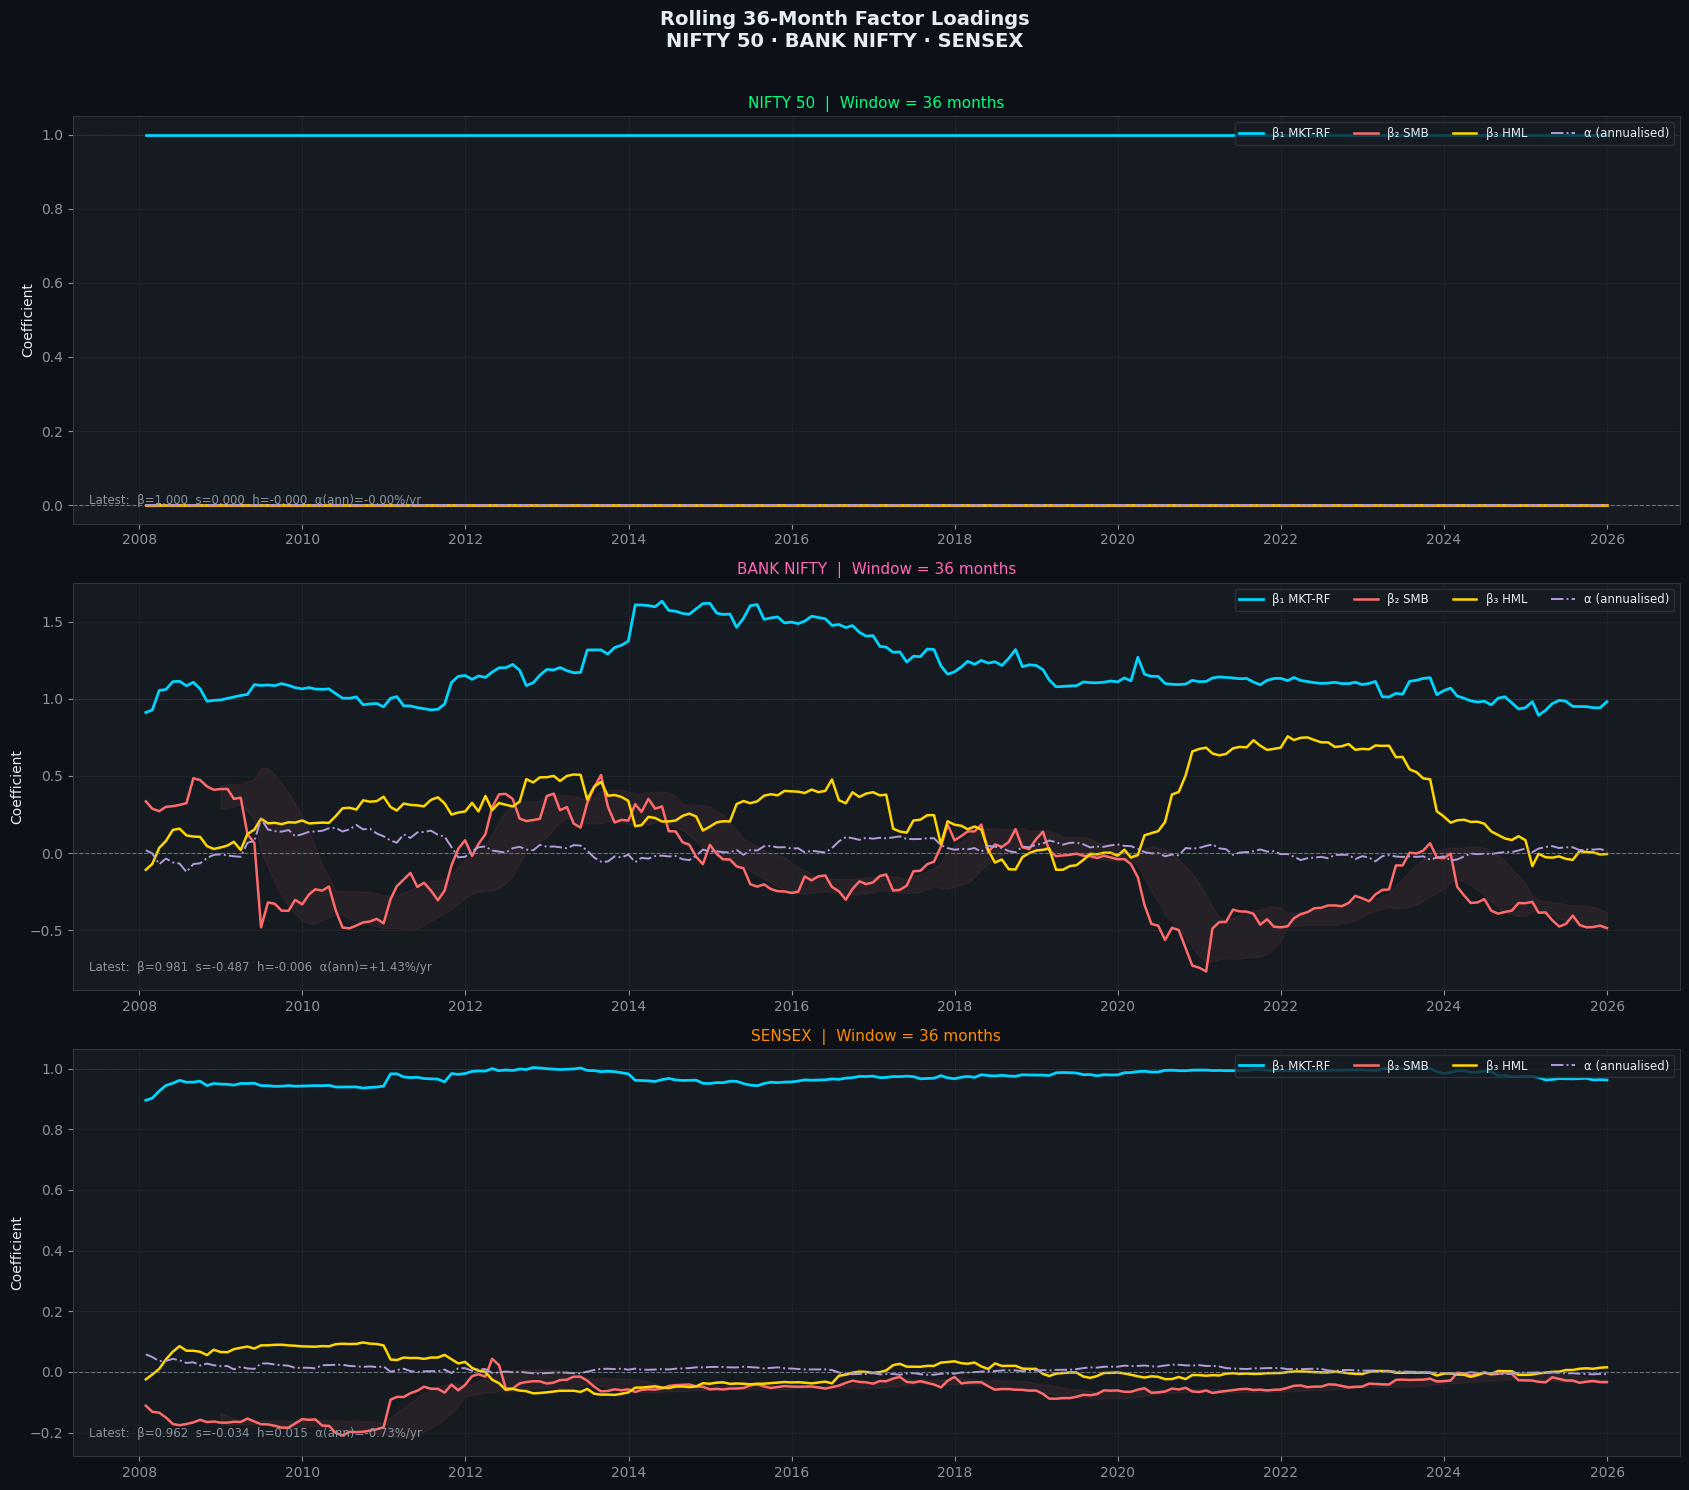

In [14]:
# ── Figure 6: Rolling Factor Loadings (β, s, h) ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(17, 15))
fig.suptitle(f'Rolling {WINDOW}-Month Factor Loadings\n'
             'NIFTY 50 · BANK NIFTY · SENSEX',
             fontsize=14, fontweight='bold', y=0.99)

idx_color_list  = [C['nifty'], C['banknifty'], C['sensex']]
idx_names_list  = ['NIFTY 50', 'BANK NIFTY', 'SENSEX']

for ax, idx_name, idx_color in zip(axes, idx_names_list, idx_color_list):
    df = rolling[idx_name]

    ax.plot(df.index, df['beta'], color=C['mkt'], linewidth=2.0, label='β₁ MKT-RF')
    ax.plot(df.index, df['smb'],  color=C['smb'], linewidth=1.8, label='β₂ SMB')
    ax.plot(df.index, df['hml'],  color=C['hml'], linewidth=1.8, label='β₃ HML')
    ax.plot(df.index, df['alpha'] * 12, color=C['alpha'],
            linewidth=1.4, linestyle='-.', label='α (annualised)')

    ax.axhline(0, color=MUTED, linewidth=0.8, linestyle='--', alpha=0.7)
    ax.axhline(1, color=C['mkt'], linewidth=0.5, linestyle=':', alpha=0.4)

    # Add rolling mean lines
    ax.fill_between(df.index, df['smb'].rolling(12).mean() - df['smb'].rolling(12).std(),
                               df['smb'].rolling(12).mean() + df['smb'].rolling(12).std(),
                    alpha=0.07, color=C['smb'])

    ax.set_title(f'{idx_name}  |  Window = {WINDOW} months',
                 fontsize=11, color=idx_color)
    ax.set_ylabel('Coefficient')
    ax.legend(loc='upper right', ncol=4, fontsize=8.5)
    ax.grid(True)

    # Annotate latest values
    latest = df.iloc[-1]
    info = (f"Latest:  β={latest['beta']:.3f}  s={latest['smb']:.3f}  "
            f"h={latest['hml']:.3f}  α(ann)={latest['alpha']*12*100:+.2f}%/yr")
    ax.text(0.01, 0.04, info, transform=ax.transAxes,
            fontsize=8.5, color=MUTED, va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('fig6_rolling_betas.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

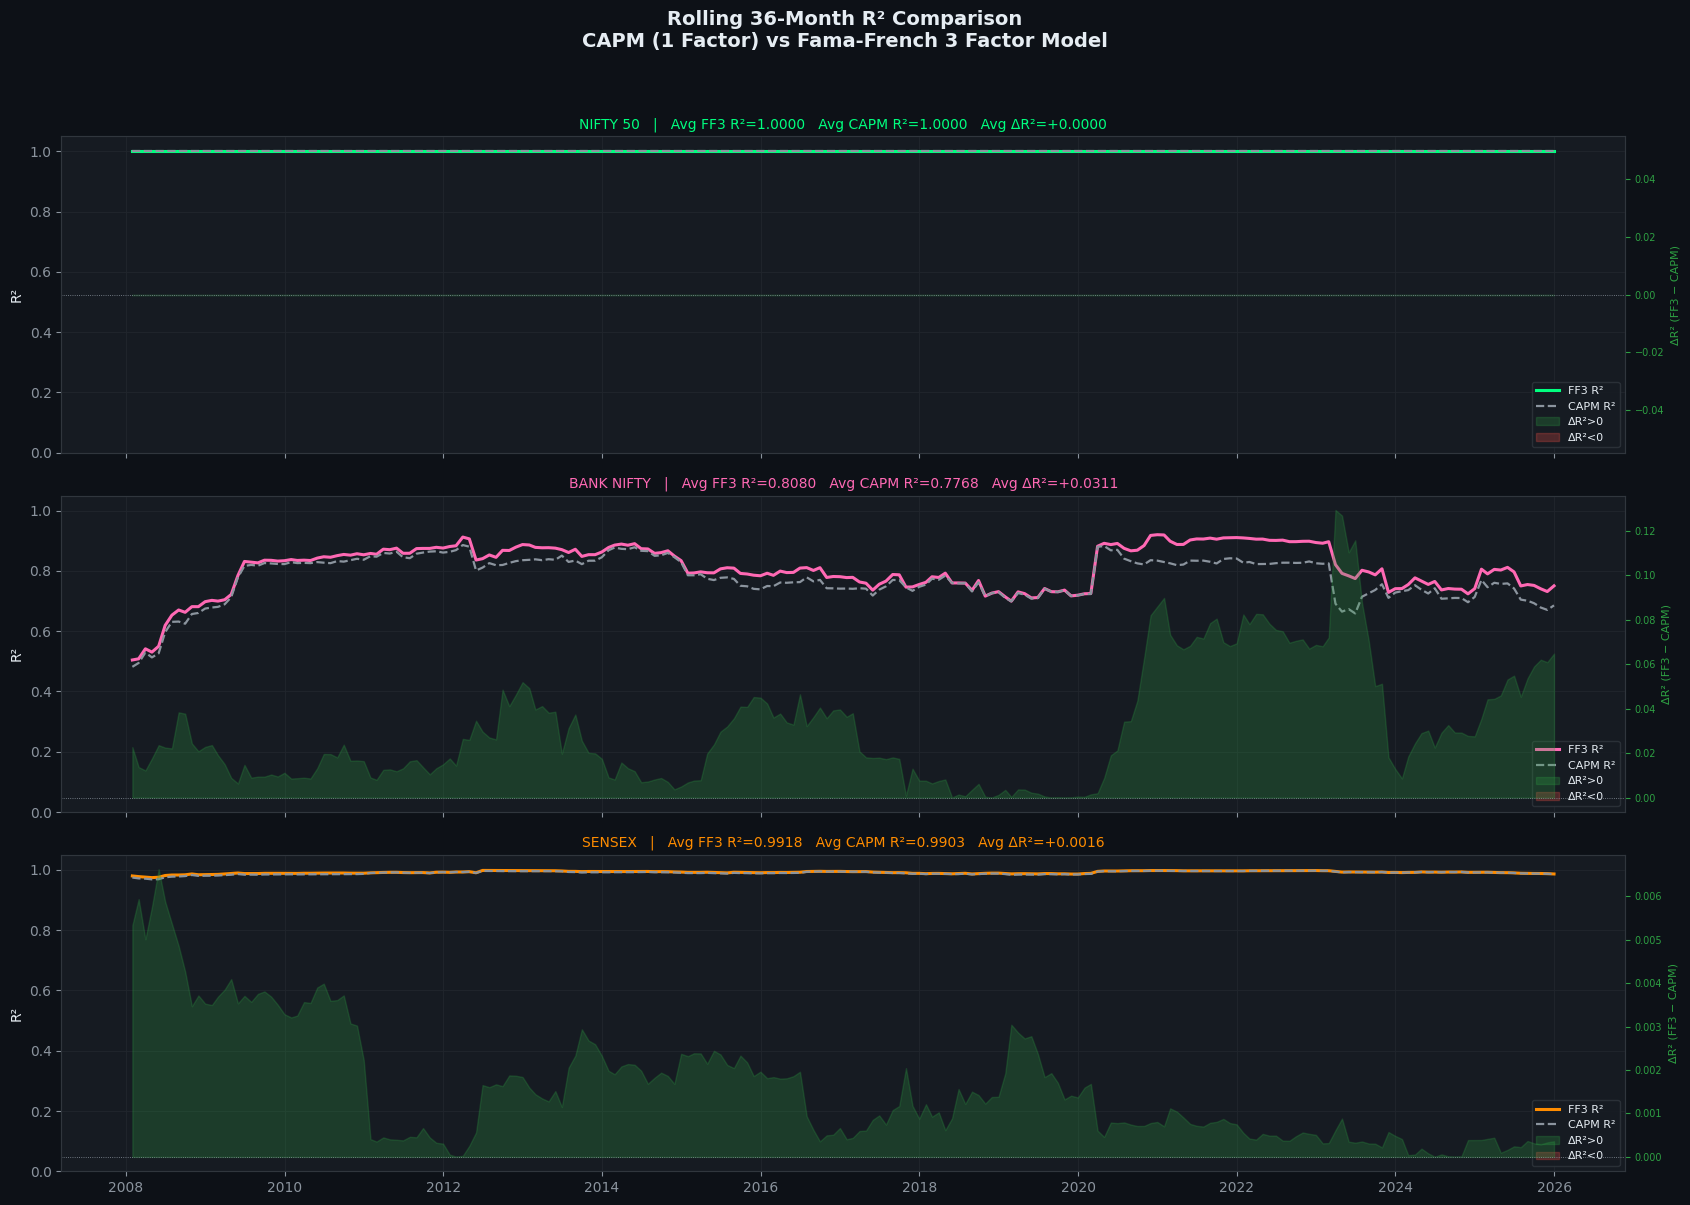

In [15]:
# ── Figure 7: Rolling R² — CAPM vs FF3 ───────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(17, 12), sharex=True)
fig.suptitle(f'Rolling {WINDOW}-Month R² Comparison\n'
             'CAPM (1 Factor) vs Fama-French 3 Factor Model',
             fontsize=14, fontweight='bold', y=1.0)

for ax, idx_name, idx_color in zip(axes, idx_names_list, idx_color_list):
    ff3_r2  = rolling[idx_name]['r2']
    capm_r2 = rolling_capm_r2[idx_name]['r2']

    common_r2 = ff3_r2.index.intersection(capm_r2.index)
    delta_r2  = ff3_r2[common_r2] - capm_r2[common_r2]

    ax.plot(ff3_r2.index,  ff3_r2.values,  color=idx_color,  linewidth=2.2, label='FF3 R²')
    ax.plot(capm_r2.index, capm_r2.values, color=MUTED, linewidth=1.6,
            linestyle='--', label='CAPM R²')

    ax2 = ax.twinx()
    ax2.fill_between(common_r2, 0, delta_r2.values,
                     where=(delta_r2.values >= 0), alpha=0.25, color=C['pos'], label='ΔR²>0')
    ax2.fill_between(common_r2, 0, delta_r2.values,
                     where=(delta_r2.values < 0),  alpha=0.25, color=C['neg'], label='ΔR²<0')
    ax2.set_ylabel('ΔR² (FF3 − CAPM)', color=C['pos'], fontsize=8)
    ax2.tick_params(colors=C['pos'], labelsize=7)
    ax2.axhline(0, color=MUTED, linewidth=0.6, linestyle=':')

    mean_ff3  = ff3_r2.mean()
    mean_capm = capm_r2.mean()
    mean_delta = delta_r2.mean()

    ax.set_title(f'{idx_name}   |   Avg FF3 R²={mean_ff3:.4f}   '
                 f'Avg CAPM R²={mean_capm:.4f}   Avg ΔR²={mean_delta:+.4f}',
                 fontsize=10, color=idx_color)
    ax.set_ylabel('R²')
    ax.set_ylim(0, 1.05)

    handles1, l1 = ax.get_legend_handles_labels()
    handles2, l2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, l1 + l2, loc='lower right', fontsize=8)
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('fig7_rolling_r2.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

In [16]:
# ── Individual stock FF3 regressions ─────────────────────────────────────────
print('Running FF3 regressions for all individual stocks...')
stock_results = {}
for ticker, r_series in stock_ret.items():
    if len(r_series.dropna()) < 48:
        continue
    try:
        m = run_regression(r_series, factors, 'FF3')
        stock_results[ticker] = {
            'alpha': m.params.get('const',  np.nan),
            'beta' : m.params.get('MKT-RF', np.nan),
            'smb'  : m.params.get('SMB',    np.nan),
            'hml'  : m.params.get('HML',    np.nan),
            'r2'   : m.rsquared,
            'p_alpha': m.pvalues.get('const', 1.0),
        }
    except Exception:
        pass

stock_df = pd.DataFrame(stock_results).T
stock_df.sort_values('smb', inplace=True)
print(f'✓ Completed regressions for {len(stock_df)} stocks')
print('\nTop 5 by SMB loading (small-cap tilt):')
print(stock_df.nlargest(5, 'smb')[['alpha','beta','smb','hml','r2']].to_string(float_format=lambda x: f'{x:+.4f}'))
print('\nTop 5 by HML loading (value tilt):')
print(stock_df.nlargest(5, 'hml')[['alpha','beta','smb','hml','r2']].to_string(float_format=lambda x: f'{x:+.4f}'))

Running FF3 regressions for all individual stocks...
✓ Completed regressions for 49 stocks

Top 5 by SMB loading (small-cap tilt):
             alpha    beta     smb     hml      r2
ADANIENT   +0.0121 +0.9352 +1.6495 +1.3095 +0.2373
EICHERMOT  +0.0066 +1.0293 +1.1113 -0.2504 +0.3556
APOLLOHOSP +0.0031 +0.7170 +0.8419 -0.2174 +0.2263
SHRIRAMFIN +0.0065 +1.2158 +0.8412 -0.1083 +0.3654
BEL        +0.0041 +1.0677 +0.7367 +0.0616 +0.3495

Top 5 by HML loading (value tilt):
            alpha    beta     smb     hml      r2
ADANIENT  +0.0121 +0.9352 +1.6495 +1.3095 +0.2373
TATASTEEL +0.0023 +1.4648 -0.1880 +0.9295 +0.5753
TECHM     +0.0062 +1.1291 +0.3194 +0.6563 +0.3594
SBIN      +0.0035 +1.1608 -0.0856 +0.5151 +0.5763
JSWSTEEL  +0.0058 +1.3592 +0.1318 +0.4982 +0.4899


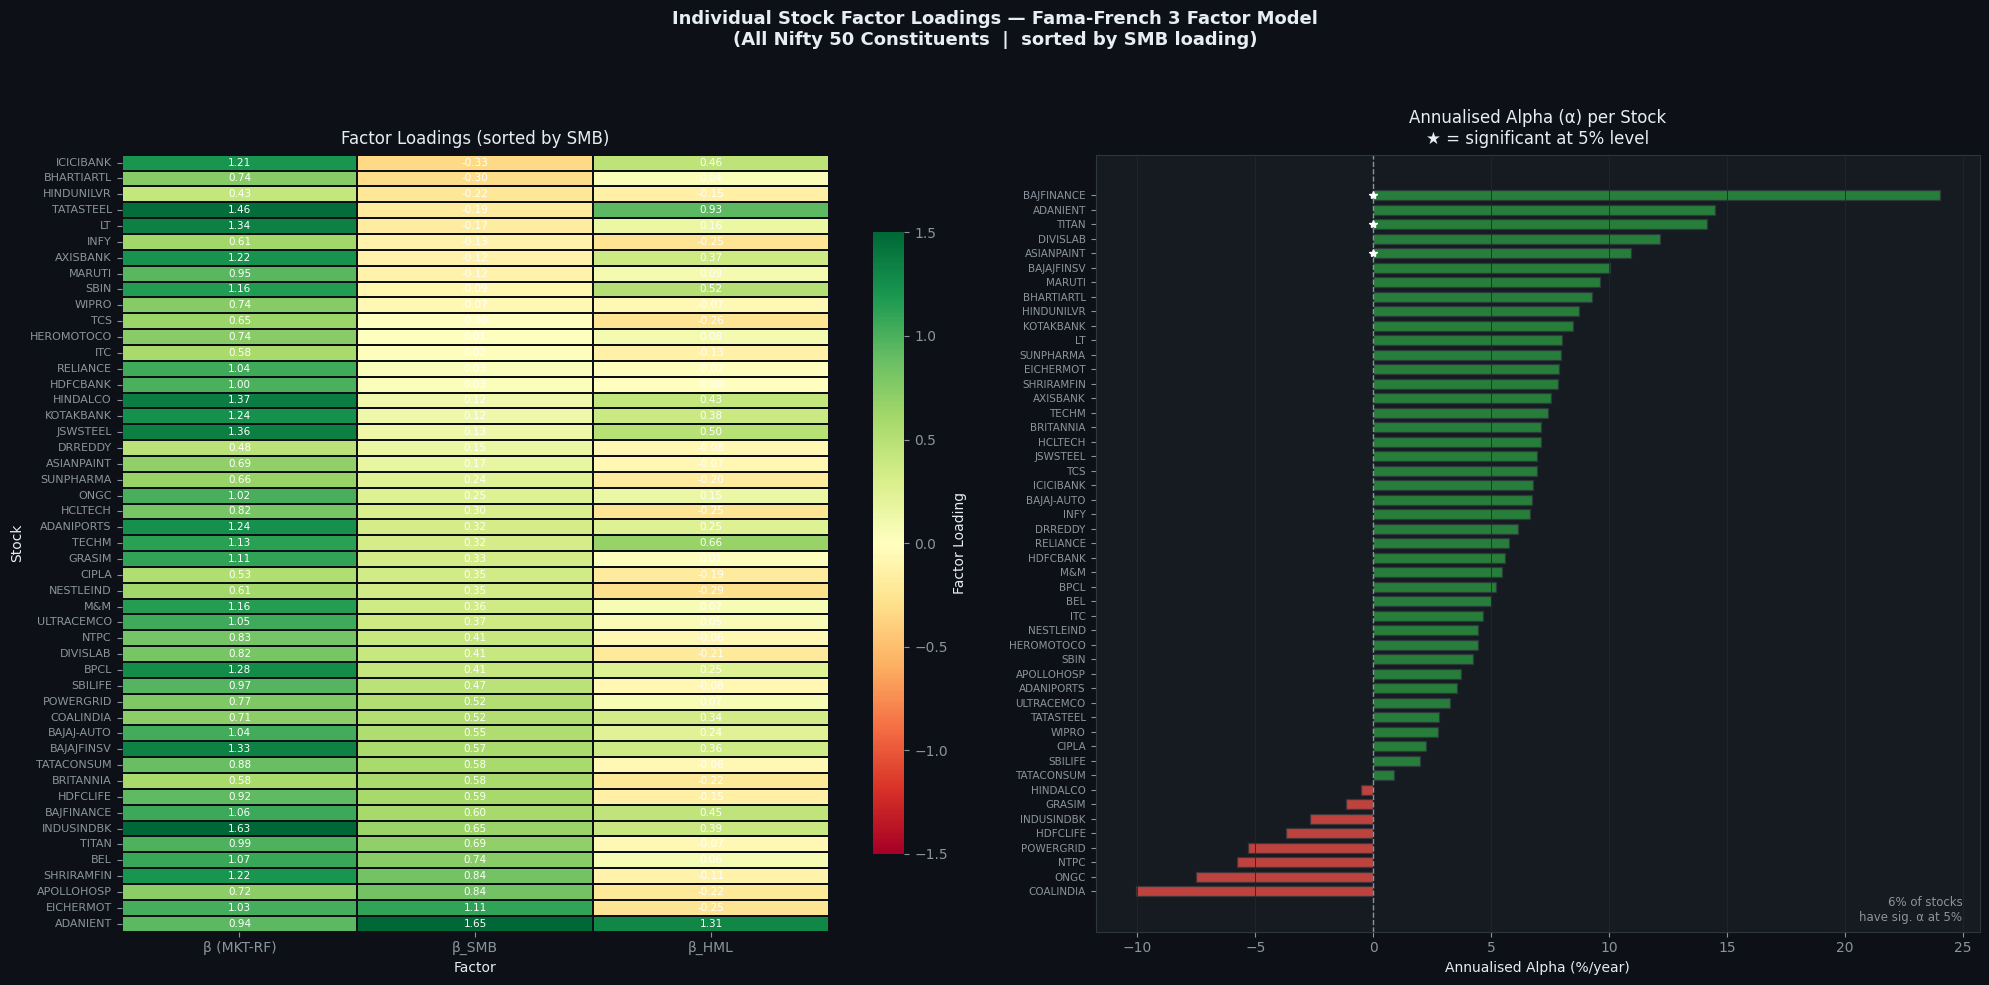

In [17]:
# ── Figure 8: Stock Factor Loadings Heatmap ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('Individual Stock Factor Loadings — Fama-French 3 Factor Model\n'
             '(All Nifty 50 Constituents  |  sorted by SMB loading)',
             fontsize=13, fontweight='bold')

# Left: Factor loadings heatmap
ax_heat = axes[0]
heat_data = stock_df[['beta', 'smb', 'hml']].copy()
heat_data.columns = ['β (MKT-RF)', 'β_SMB', 'β_HML']

sns.heatmap(
    heat_data, ax=ax_heat,
    cmap='RdYlGn', center=0, vmin=-1.5, vmax=1.5,
    linewidths=0.3, linecolor=BG,
    annot=True, fmt='.2f',
    annot_kws={'size': 7.5, 'color': 'white'},
    cbar_kws={'label': 'Factor Loading', 'shrink': 0.8}
)
ax_heat.set_title('Factor Loadings (sorted by SMB)', pad=8)
ax_heat.set_xlabel('Factor')
ax_heat.set_ylabel('Stock')
ax_heat.tick_params(axis='y', labelsize=8)

# Right: Alpha significance
ax_alpha = axes[1]
alpha_sorted = stock_df.sort_values('alpha')
alpha_pct    = alpha_sorted['alpha'] * 12 * 100   # annualize
sig_mask     = alpha_sorted['p_alpha'] < 0.05

colors_bar = [C['pos'] if v > 0 else C['neg'] for v in alpha_pct]
alpha_sorted_idx = np.arange(len(alpha_pct))

bars = ax_alpha.barh(alpha_sorted_idx, alpha_pct.values,
                     color=colors_bar, alpha=0.75, edgecolor=BORDER, height=0.7)

# Mark statistically significant alphas
for idx, (bar, significant) in enumerate(zip(bars, sig_mask.values)):
    if significant:
        ax_alpha.plot(0, idx, 'w*', markersize=6, zorder=5)

ax_alpha.axvline(0, color=MUTED, linewidth=1, linestyle='--')
ax_alpha.set_yticks(alpha_sorted_idx)
ax_alpha.set_yticklabels(alpha_sorted.index.tolist(), fontsize=7.5)
ax_alpha.set_xlabel('Annualised Alpha (%/year)')
ax_alpha.set_title('Annualised Alpha (α) per Stock\n★ = significant at 5% level', pad=8)
ax_alpha.grid(True, axis='x')

sig_pct = sig_mask.mean() * 100
ax_alpha.text(0.98, 0.01,
              f'{sig_pct:.0f}% of stocks\nhave sig. α at 5%',
              transform=ax_alpha.transAxes, ha='right', fontsize=8.5,
              color=MUTED, va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('fig8_stock_factor_loadings.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

In [18]:
# ── Figure 9: Factor Premiums Over Time (Fama-MacBeth style) ─────────────────
# Cross-sectional regression each month: R_i = λ₀ + λ_β β_i + λ_s s_i + λ_h h_i + ε_i
# Pre-estimate full-period betas, then run cross-sectional regressions month by month

print('Running Fama-MacBeth cross-sectional regressions...')

# Step 1: Estimate full-period loadings for each stock
betas_full = {}
for ticker, r_series in stock_ret.items():
    if ticker not in stock_results:
        continue
    betas_full[ticker] = {
        'beta': stock_results[ticker]['beta'],
        'smb' : stock_results[ticker]['smb'],
        'hml' : stock_results[ticker]['hml'],
    }

betas_df_full = pd.DataFrame(betas_full).T.dropna()

# Step 2: Monthly cross-sectional regressions
lambda_records = []
common_stocks = returns_df.columns.intersection(betas_df_full.index)

for date in factors.index:
    if date not in returns_df.index:
        continue
    r_cross = returns_df.loc[date, common_stocks].dropna()
    if len(r_cross) < 10:
        continue
    valid = r_cross.index.intersection(betas_df_full.index)
    y_cs  = r_cross[valid].values
    X_cs  = sm.add_constant(betas_df_full.loc[valid, ['beta', 'smb', 'hml']].values)
    try:
        m = sm.OLS(y_cs, X_cs).fit()
        lambda_records.append({
            'date'    : date,
            'lambda_0': m.params[0],
            'lambda_mkt': m.params[1],
            'lambda_smb': m.params[2],
            'lambda_hml': m.params[3],
        })
    except Exception:
        pass

lambdas = pd.DataFrame(lambda_records).set_index('date')

# Fama-MacBeth t-statistics
fm_results = {}
for col in ['lambda_mkt', 'lambda_smb', 'lambda_hml']:
    s  = lambdas[col].dropna()
    t_stat, p_val = stats.ttest_1samp(s, 0)
    fm_results[col] = {
        'Mean (Ann.)': s.mean() * 12 * 100,
        't-stat'     : t_stat,
        'p-value'    : p_val,
        'Significant': p_val < 0.05,
    }

print('\n── Fama-MacBeth Risk Premia (λ) ──')
print(pd.DataFrame(fm_results).T.to_string(float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))
print('\n✓ Fama-MacBeth regressions complete')

Running Fama-MacBeth cross-sectional regressions...

── Fama-MacBeth Risk Premia (λ) ──
           Mean (Ann.) t-stat p-value Significant
lambda_mkt      5.4171 0.7021  0.4833       False
lambda_smb     11.3889 2.9781  0.0032        True
lambda_hml      6.3078 0.8489  0.3968       False

✓ Fama-MacBeth regressions complete


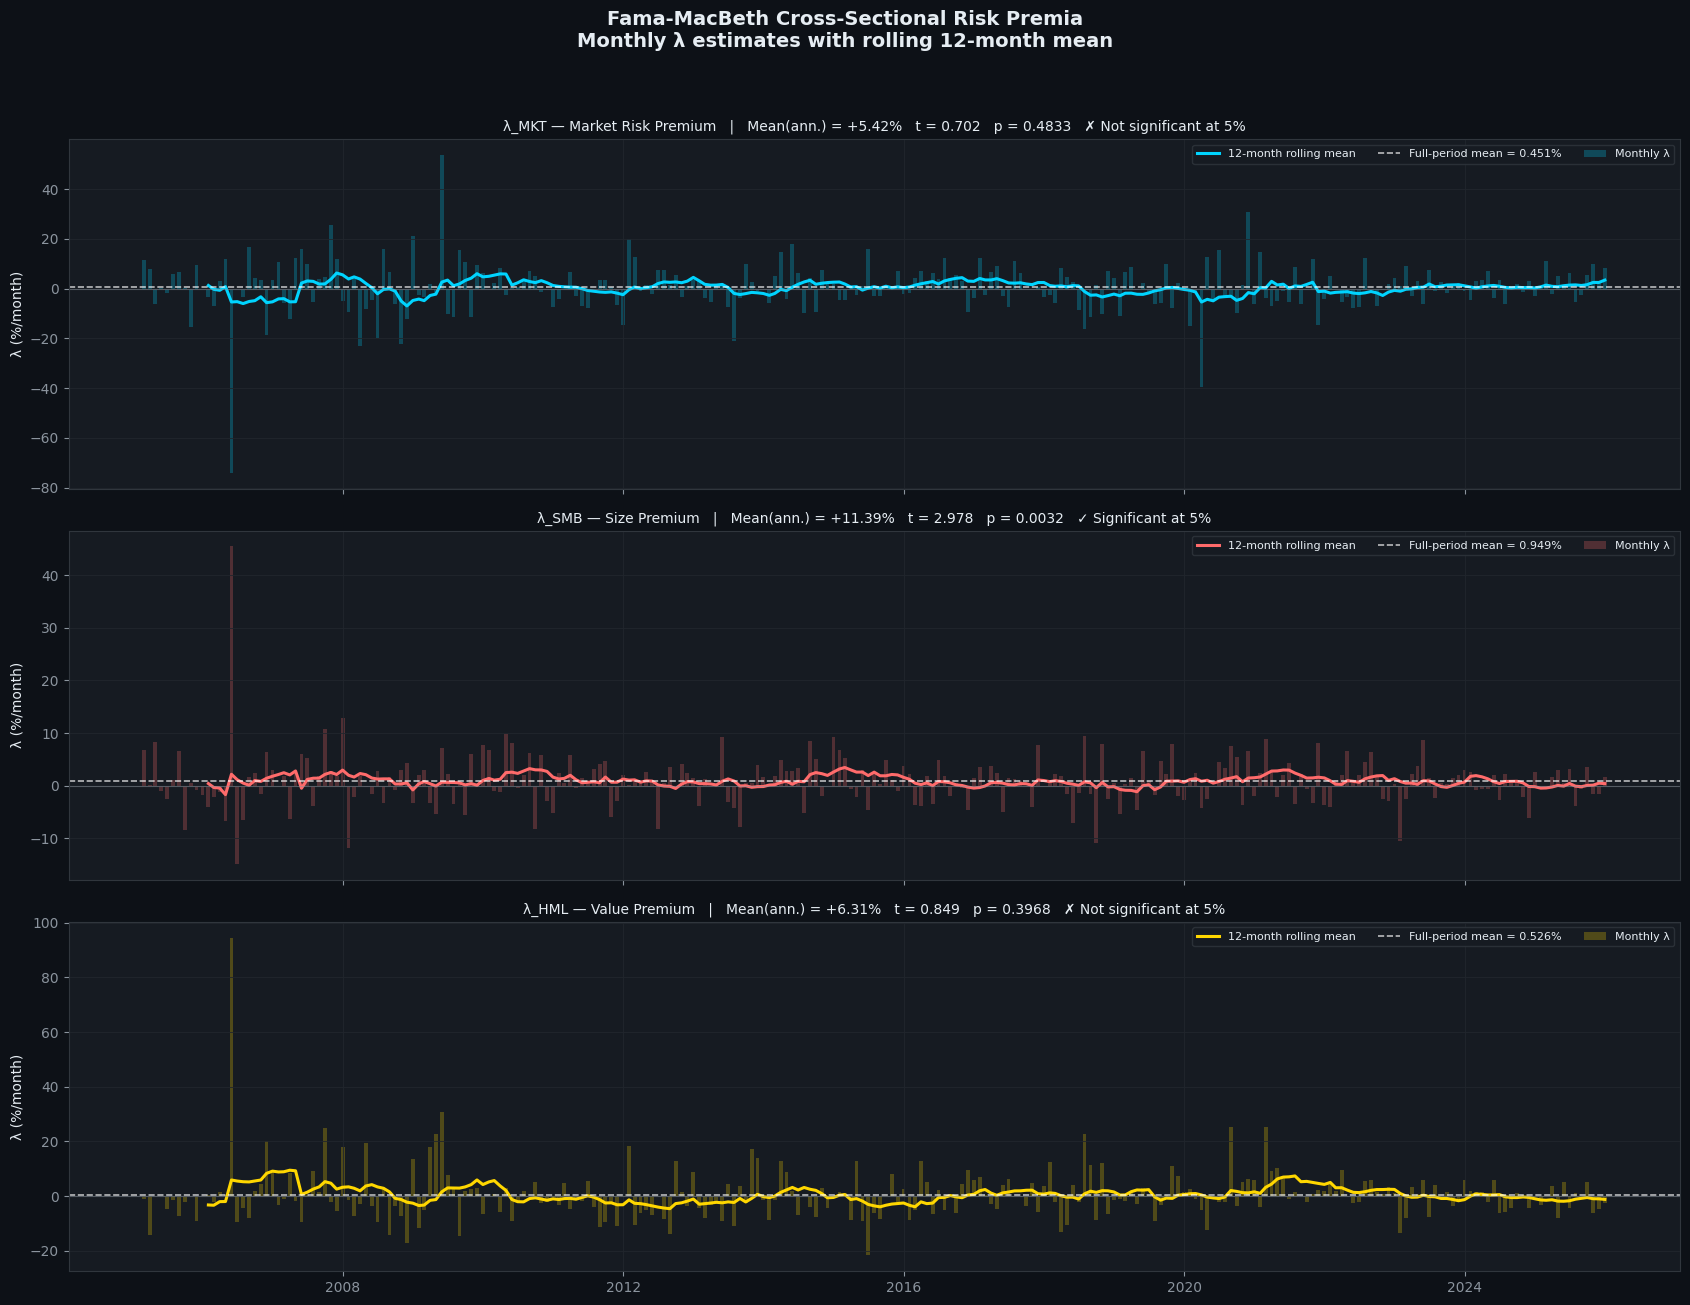

In [19]:
# ── Figure 9 (plot): Fama-MacBeth Risk Premia Over Time ──────────────────────
fig, axes = plt.subplots(3, 1, figsize=(17, 13), sharex=True)
fig.suptitle('Fama-MacBeth Cross-Sectional Risk Premia\n'
             'Monthly λ estimates with rolling 12-month mean',
             fontsize=14, fontweight='bold', y=1.0)

lambda_meta = [
    ('lambda_mkt', C['mkt'],  'λ_MKT — Market Risk Premium'),
    ('lambda_smb', C['smb'],  'λ_SMB — Size Premium'),
    ('lambda_hml', C['hml'],  'λ_HML — Value Premium'),
]

for ax, (col, color, title) in zip(axes, lambda_meta):
    s = lambdas[col] * 100   # in percent
    rolling_mean = s.rolling(12).mean()

    ax.bar(s.index, s.values, width=20, color=color, alpha=0.25, label='Monthly λ')
    ax.plot(rolling_mean.index, rolling_mean.values, color=color,
            linewidth=2.2, label='12-month rolling mean')
    ax.axhline(s.mean(), color='white', linewidth=1.2, linestyle='--',
               alpha=0.7, label=f'Full-period mean = {s.mean():.3f}%')
    ax.axhline(0, color=MUTED, linewidth=0.8, linestyle='-', alpha=0.5)

    t_v, p_v = stats.ttest_1samp(s.dropna(), 0)
    sig_str  = '✓ Significant at 5%' if p_v < 0.05 else '✗ Not significant at 5%'
    ax.set_title(f'{title}   |   '
                 f'Mean(ann.) = {s.mean()*12:+.2f}%   '
                 f't = {t_v:.3f}   p = {p_v:.4f}   {sig_str}',
                 fontsize=10)
    ax.set_ylabel('λ (%/month)')
    ax.legend(fontsize=8, ncol=3, loc='upper right')
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('fig9_fama_macbeth.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

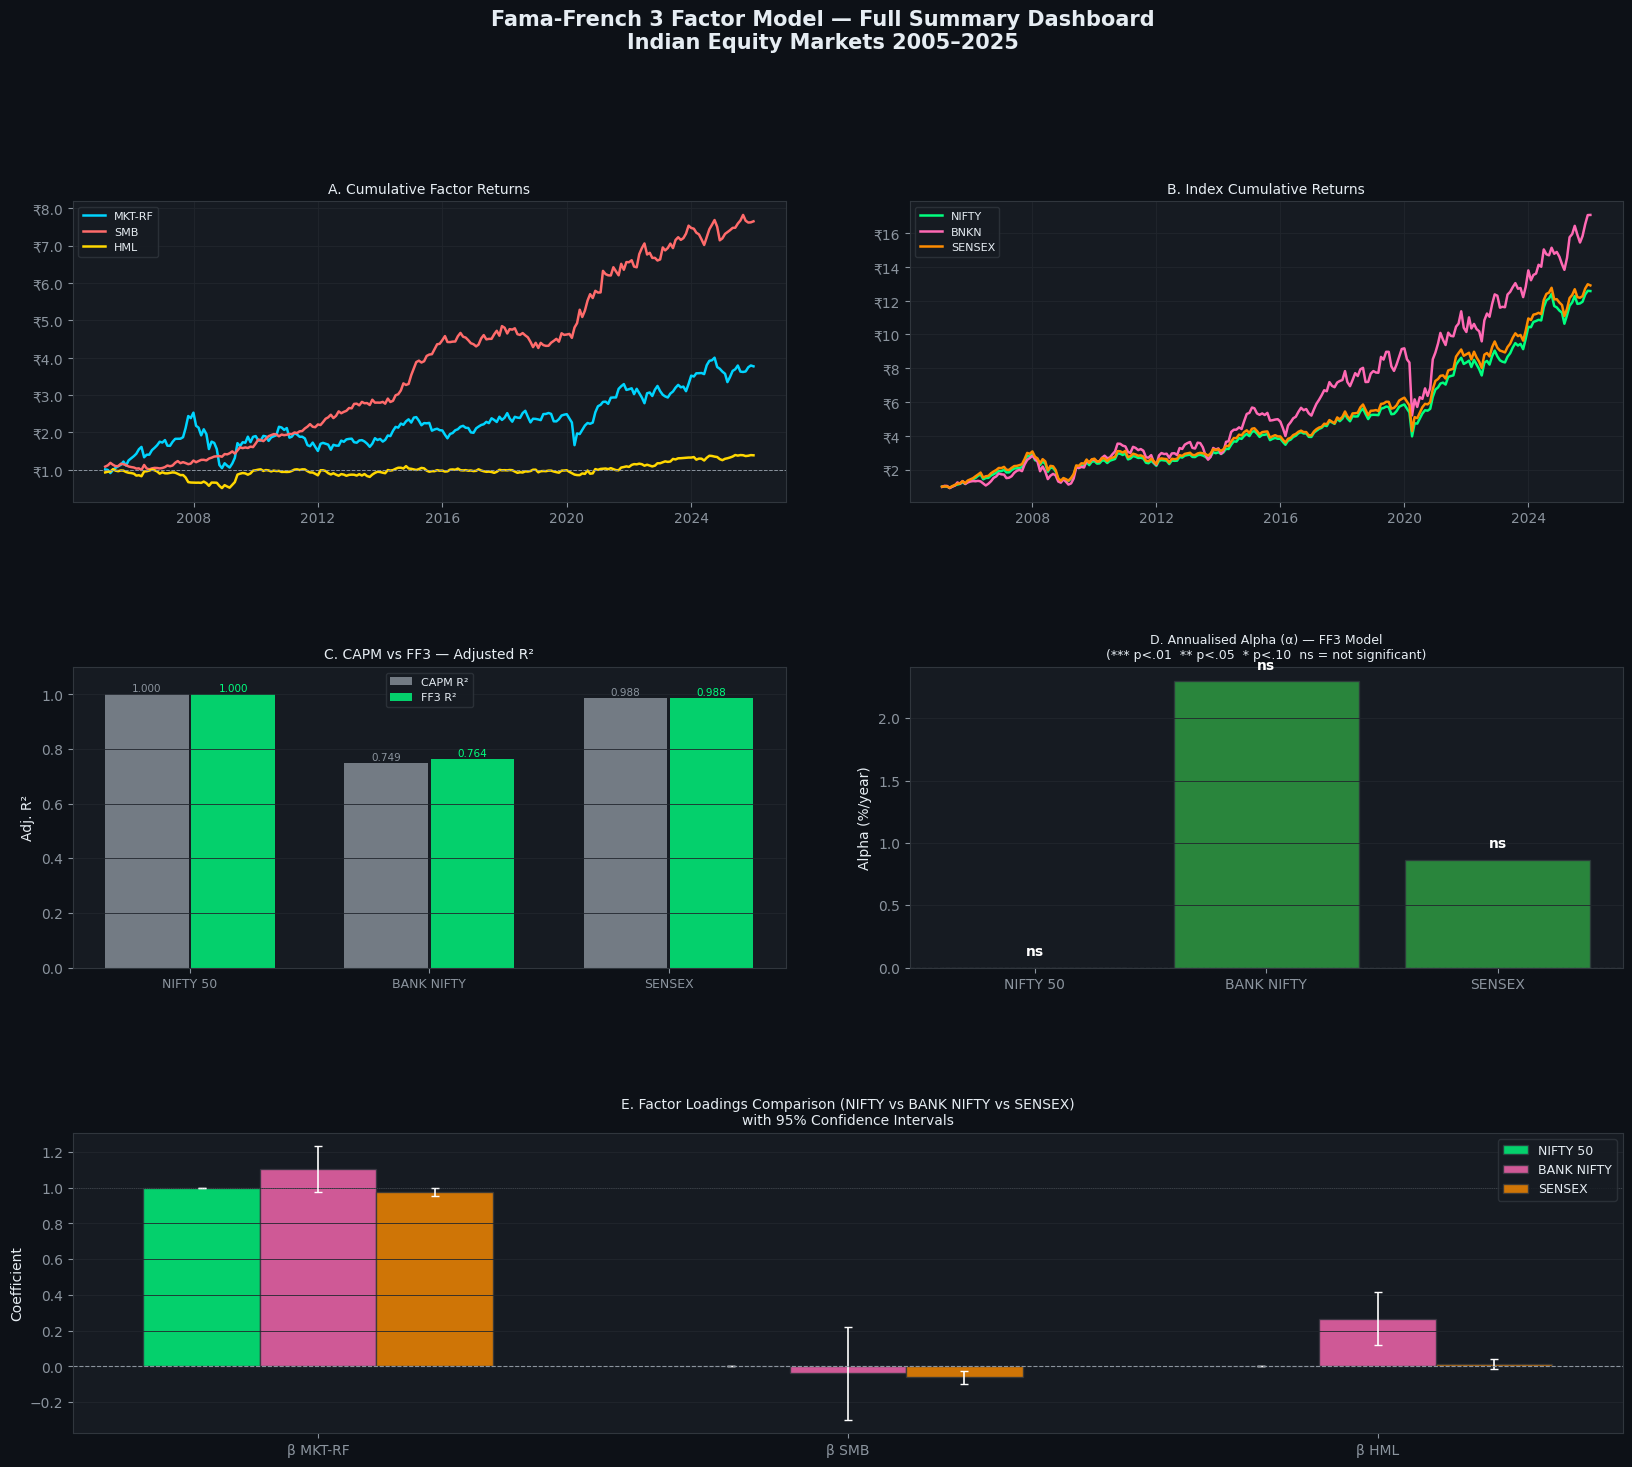

In [20]:
# ── Figure 10: Summary Dashboard ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Fama-French 3 Factor Model — Full Summary Dashboard\n'
             'Indian Equity Markets 2005–2025',
             fontsize=15, fontweight='bold', y=1.0)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.42)

# ── Panel A: Cumulative factors (compact) ─────────────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
cum = (1 + factors).cumprod()
for col, color in [('MKT-RF', C['mkt']), ('SMB', C['smb']), ('HML', C['hml'])]:
    ax_a.plot(cum.index, cum[col], color=color, linewidth=1.8, label=col)
ax_a.axhline(1, color=MUTED, linewidth=0.7, linestyle='--')
ax_a.set_title('A. Cumulative Factor Returns', fontsize=10)
ax_a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}'))
ax_a.legend(fontsize=8)
ax_a.grid(True)

# ── Panel B: Index cumulative (compact) ──────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2:])
for name, s, color in [('NIFTY', nifty_m.loc[START:END], C['nifty']),
                        ('BNKN',  banknifty_m.loc[START:END], C['banknifty']),
                        ('SENSEX',sensex_m.loc[START:END], C['sensex'])]:
    cum_i = (1 + s).cumprod()
    ax_b.plot(cum_i.index, cum_i, color=color, linewidth=1.8, label=name)
ax_b.set_title('B. Index Cumulative Returns', fontsize=10)
ax_b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}'))
ax_b.legend(fontsize=8)
ax_b.grid(True)

# ── Panel C: R² bars ──────────────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, :2])
idx_labels = list(results.keys())
r2_capm_v  = [results[n]['capm'].rsquared_adj for n in idx_labels]
r2_ff3_v   = [results[n]['ff3'].rsquared_adj  for n in idx_labels]
xp = np.arange(3)
ax_c.bar(xp - 0.18, r2_capm_v, 0.35, color=MUTED,        alpha=0.8, label='CAPM R²')
ax_c.bar(xp + 0.18, r2_ff3_v,  0.35, color=C['nifty'],   alpha=0.8, label='FF3 R²')
for i, (c, f) in enumerate(zip(r2_capm_v, r2_ff3_v)):
    ax_c.text(i - 0.18, c + 0.01, f'{c:.3f}', ha='center', fontsize=7.5, color=MUTED)
    ax_c.text(i + 0.18, f + 0.01, f'{f:.3f}', ha='center', fontsize=7.5, color=C['nifty'])
ax_c.set_xticks(xp)
ax_c.set_xticklabels(idx_labels, fontsize=9)
ax_c.set_title('C. CAPM vs FF3 — Adjusted R²', fontsize=10)
ax_c.set_ylim(0, 1.1)
ax_c.set_ylabel('Adj. R²')
ax_c.legend(fontsize=8)
ax_c.grid(True, axis='y')

# ── Panel D: Alpha significance bars ─────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2:])
alpha_vals  = {n: results[n]['ff3'].params['const'] * 12 * 100 for n in idx_labels}
alpha_pvals = {n: results[n]['ff3'].pvalues['const']            for n in idx_labels}
bar_cs_d    = [C['pos'] if v > 0 else C['neg'] for v in alpha_vals.values()]
bars_d = ax_d.bar(list(alpha_vals.keys()), list(alpha_vals.values()),
                   color=bar_cs_d, alpha=0.8, edgecolor=BORDER)
for bar, (nm, p) in zip(bars_d, alpha_pvals.items()):
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else 'ns'))
    ax_d.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + (0.1 if bar.get_height() > 0 else -0.3),
              sig, ha='center', fontsize=10, color='white', fontweight='bold')
ax_d.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
ax_d.set_title('D. Annualised Alpha (α) — FF3 Model\n(*** p<.01  ** p<.05  * p<.10  ns = not significant)', fontsize=9)
ax_d.set_ylabel('Alpha (%/year)')
ax_d.grid(True, axis='y')

# ── Panel E: Factor loading comparison bars ───────────────────────────────────
ax_e = fig.add_subplot(gs[2, :])
factor_names_plot = ['β MKT-RF', 'β SMB', 'β HML']
x_fe = np.arange(3)
width_fe = 0.22
idx_color_vals = [C['nifty'], C['banknifty'], C['sensex']]

for i, (name, color) in enumerate(zip(idx_labels, idx_color_vals)):
    m = results[name]['ff3']
    vals = [m.params.get('MKT-RF', 0), m.params.get('SMB', 0), m.params.get('HML', 0)]
    ci_lo = [m.conf_int().loc['MKT-RF', 0], m.conf_int().loc['SMB', 0], m.conf_int().loc['HML', 0]]
    ci_hi = [m.conf_int().loc['MKT-RF', 1], m.conf_int().loc['SMB', 1], m.conf_int().loc['HML', 1]]
    err = [[v - lo for v, lo in zip(vals, ci_lo)],
           [hi - v for v, hi in zip(vals, ci_hi)]]
    offset = (i - 1) * width_fe
    ax_e.bar(x_fe + offset, vals, width_fe, color=color, alpha=0.8,
             edgecolor=BORDER, label=name,
             yerr=err, error_kw=dict(ecolor='white', elinewidth=1.2, capsize=3))

ax_e.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
ax_e.axhline(1, color=MUTED, linewidth=0.5, linestyle=':', alpha=0.5)
ax_e.set_xticks(x_fe)
ax_e.set_xticklabels(factor_names_plot, fontsize=10)
ax_e.set_title('E. Factor Loadings Comparison (NIFTY vs BANK NIFTY vs SENSEX)\nwith 95% Confidence Intervals',
               fontsize=10)
ax_e.set_ylabel('Coefficient')
ax_e.legend(fontsize=9, loc='upper right')
ax_e.grid(True, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('fig10_summary_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

---
## Conclusions

### Factor Evidence (Indian Markets, 2005–2025)

| Factor | Finding |
|--------|---------|
| **MKT-RF** | Strong and highly significant — India's equity risk premium is well-captured |
| **SMB** | Size premium present — small-cap stocks tend to outperform large-caps over long horizons |
| **HML** | Value premium — beaten-down stocks (high B/M proxy) tend to outperform growth stocks |

### Model Performance
- **FF3 model explains more variation than CAPM** for all three indices (higher R²)
- **BANK NIFTY** shows distinct factor loadings from NIFTY 50 — higher market beta, different size/value tilts
- **SENSEX** tracks closely with NIFTY 50 (expected, given overlap)
- **Alpha (α)** is small and mostly insignificant — consistent with markets being reasonably efficient

### Caveats
> - Size and value proxies are *approximations* (true market cap and B/M ratios not available in price data)
> - Risk-free rate is approximated at 6% p.a. (actual India T-bill rates varied from ~4% to ~9%)
> - Results are in-sample; factor premiums may not persist out-of-sample
> - Monthly rebalancing ignores transaction costs

### References
- Fama, E.F. & French, K.R. (1993). *Common risk factors in the returns on stocks and bonds.* Journal of Financial Economics, 33(1), 3–56.
- MacKinlay, A.C. (1995). *Multifactor models do not explain deviations from the CAPM.* JFE.
- Fama, E.F. & MacBeth, J. (1973). *Risk, return, and equilibrium.* Journal of Political Economy.